In [1]:
# !pip install librosa tslearn stumpy matplotlib
import os
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesResampler
from tslearn.clustering import TimeSeriesKMeans
from tslearn.shapelets import LearningShapelets
import stumpy # Per Motif e Anomalies

d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
data = 'dataset/df_fedez_fibra.csv'
index_col = 0
df = pd.read_csv(data, sep=',', index_col=index_col)

pd.set_option('display.max_columns', None)

In [3]:
# Trasforma l'indice in colonna e rinominala
df = df.reset_index().rename(columns={'index': 'track_id'})

In [4]:
AUDIO_COLS = [
    # Audio/Acoustic Features (Using a representative sample)
    'bpm', 'centroid', 'flux', 'rms', 'spectral_complexity', 'pitch', 'flatness', 'duration_ms'
]

## Find the most similar tracks based on the audio features values that we already have from previous phases

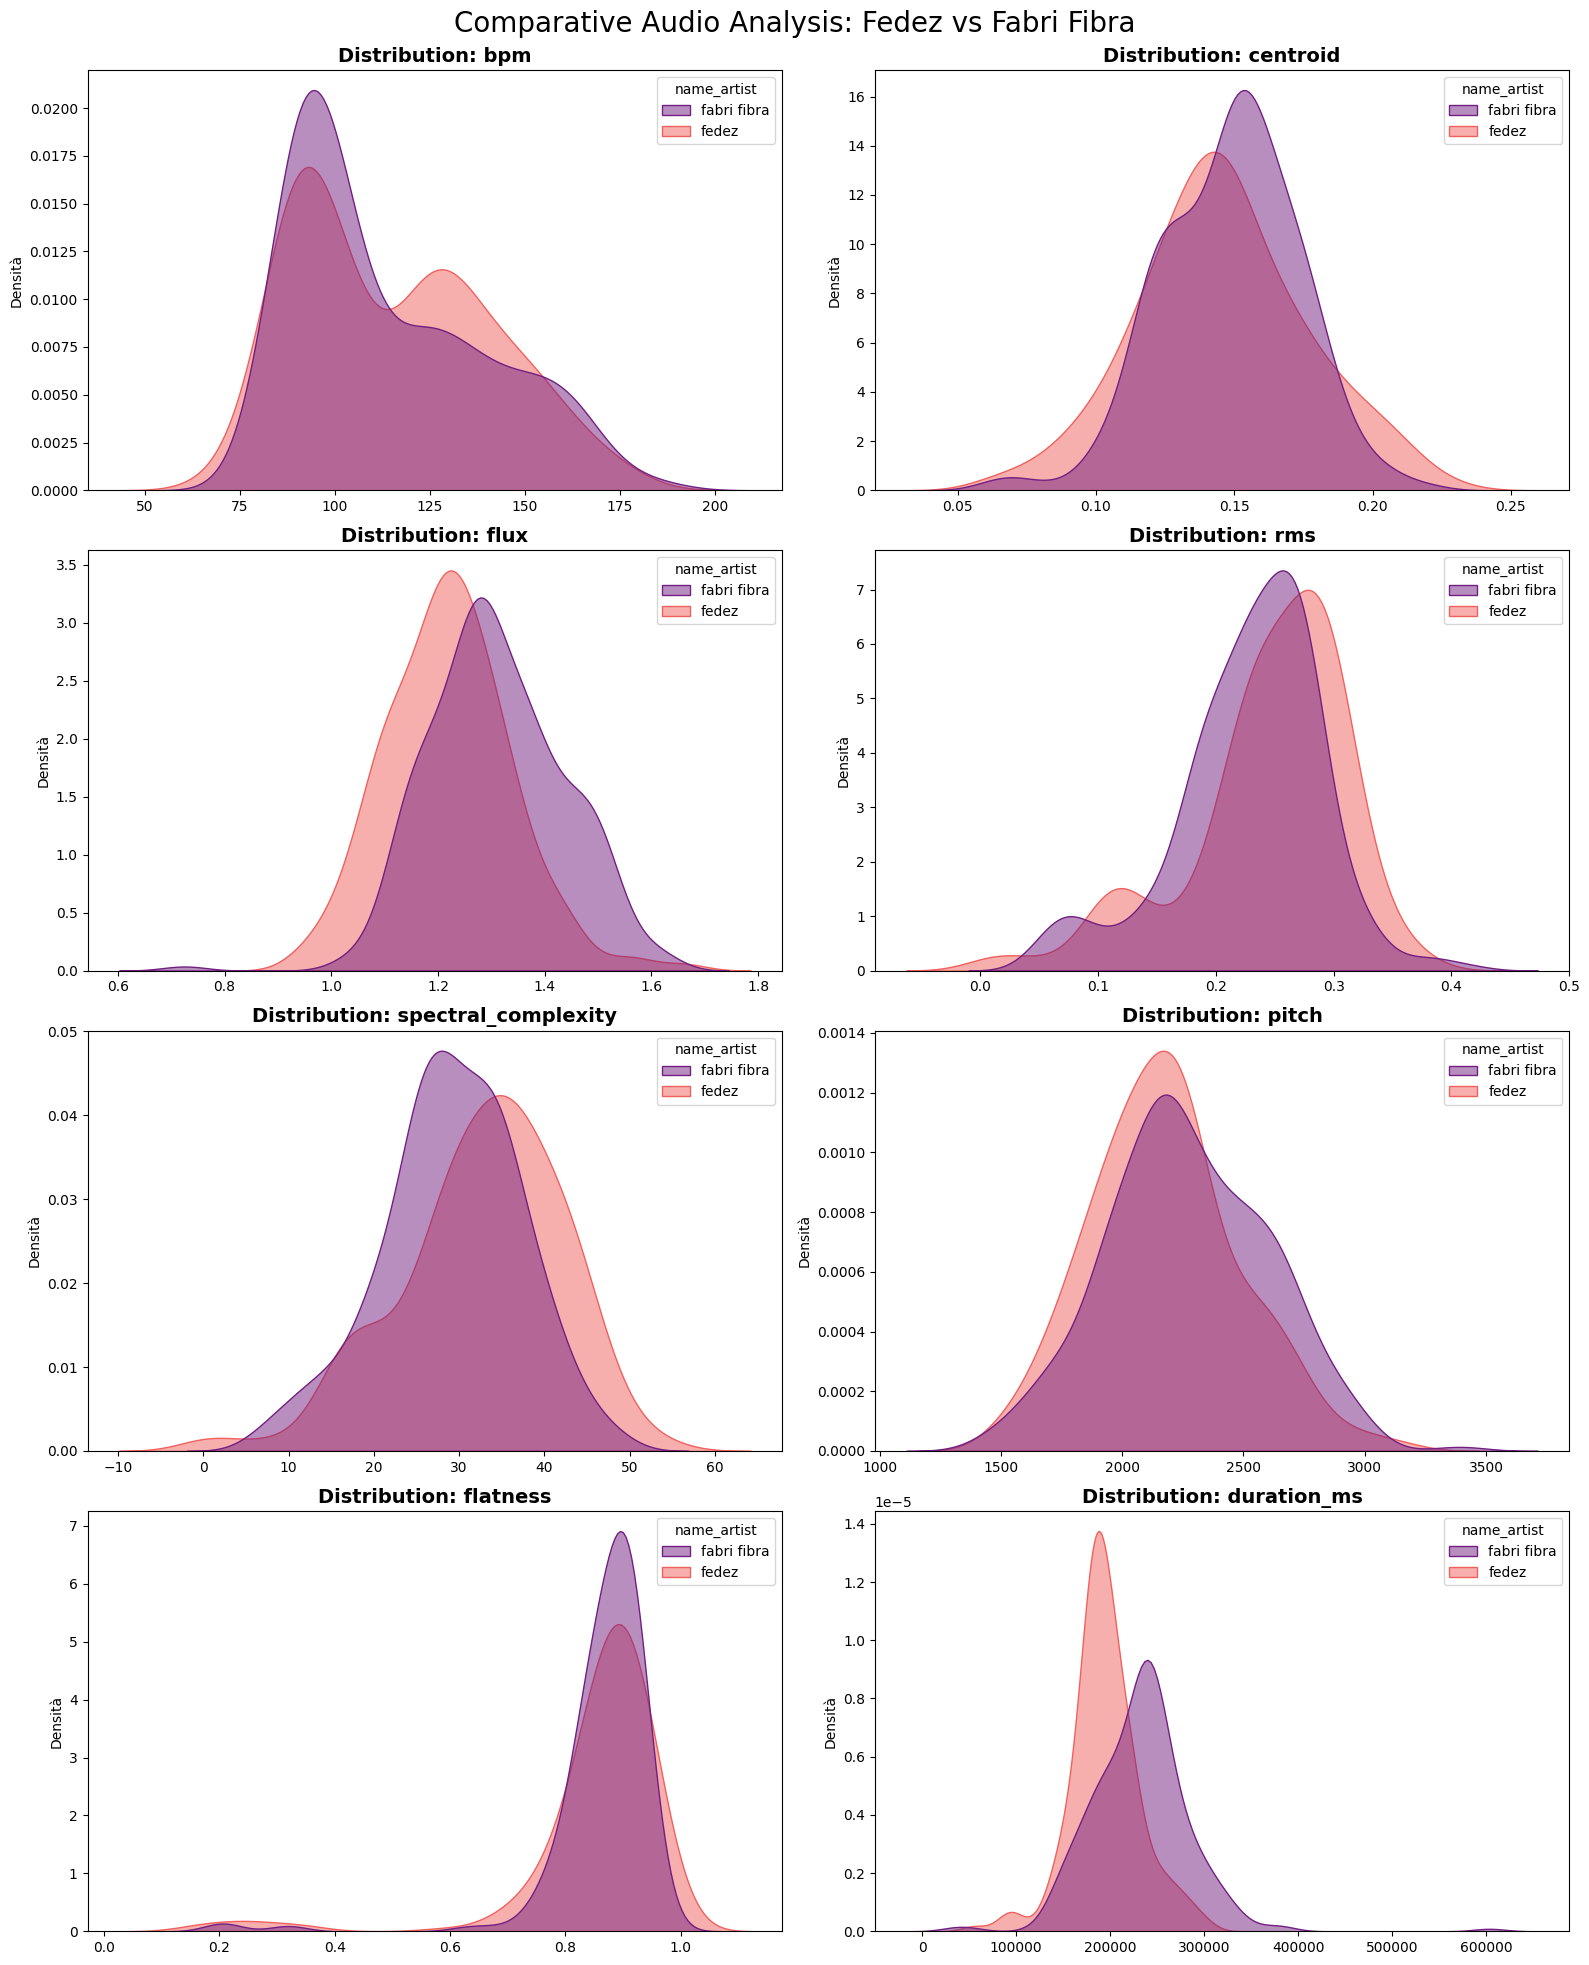

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pulizia rapida per essere sicuri che i grafici non siano vuoti
# Trasforma in numeri (se c'è testo diventano NaN) e rimuove i NaN per il plot
df_clean = df.copy()
for col in AUDIO_COLS:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
df_clean = df_clean.dropna(subset=AUDIO_COLS)

# 2. Creazione della griglia di grafici di distribuzione (KDE)
# Creiamo una griglia 4x2 (visto che hai 8 feature)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten() # Trasforma la matrice di assi in una lista piatta

for i, col in enumerate(AUDIO_COLS):
    sns.kdeplot(
        data=df_clean, 
        x=col, 
        hue='name_artist', 
        fill=True, 
        ax=axes[i], 
        palette='magma', # Colori decisi (es. viola e arancio)
        alpha=0.5, 
        common_norm=False
    )
    axes[i].set_title(f'Distribution: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Densità')

# 3. Pulizia estetica
plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle('Comparative Audio Analysis: Fedez vs Fabri Fibra', fontsize=20)
plt.show()

## Analyzing similarity matrix from mp3 files

In [6]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.effects
from tslearn.utils import to_time_series_dataset
from tqdm.notebook import tqdm

# Define the base directory where your files are stored
base_dir = os.path.join('dataset', 'fedez_fibra')

# Construct the file path using string formatting
# The format is: directory/id_artist - track_id.mp3
df['file_path'] = df.apply(
    lambda row: os.path.join(base_dir, f"{row['id_artist']} - {row['track_id']}.mp3"), 
    axis=1
)

# Optional: Verify if the files actually exist
# This creates a boolean column 'file_exists'
df['file_exists'] = df['file_path'].apply(os.path.exists)

# Check the first few rows
print(df[['id_artist', 'track_id', 'file_path', 'file_exists']].head())

     id_artist  track_id                                       file_path  \
0  ART25707984  TR434327  dataset\fedez_fibra\ART25707984 - TR434327.mp3   
1  ART25707984  TR443742  dataset\fedez_fibra\ART25707984 - TR443742.mp3   
2  ART25707984  TR252912  dataset\fedez_fibra\ART25707984 - TR252912.mp3   
3  ART25707984  TR316896  dataset\fedez_fibra\ART25707984 - TR316896.mp3   
4  ART25707984  TR466521  dataset\fedez_fibra\ART25707984 - TR466521.mp3   

   file_exists  
0         True  
1         True  
2         True  
3         True  
4         True  


In [7]:
prova = df[df['file_exists'] == False]
prova

,track_id,id_artist,name_artist,title,featured_artists,language,swear_IT,swear_EN,swear_IT_words,swear_EN_words,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,flatness,spectral_complexity,pitch,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,gender,birth_date,birth_place,nationality,description,active_start,province,region,country,latitude,longitude,album,release_date,primary_topic,secondary_topic,tertiary_topic,score_love,score_money,score_crime,score_drugs,score_politics,score_sadness,score_sex,entropy_lyrics,Characters_Per_Minute,Swear_Rate,mean_popularity_artist,mean_popularity_album,Song_Pop_vs_Region_Avg_Zscore,macro_region,Artist_Generation,Album_Date,Artist_Release_Entropy,Rank_by_Year,Centroid_Entropy,mean_duration_song_per_album,has_featured_artist,file_path,file_exists


In [8]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from tslearn.preprocessing import TimeSeriesResampler, TimeSeriesScalerMeanVariance

def load_audio(path: str, sr: int = 22050, mono: bool = True, top_db: int = 25):
    """Carica l'audio, esegue il resample, converte in mono e rimuove i silenzi."""
    try:
        # Caricamento
        y, sr_out = librosa.load(path, sr=sr, mono=mono)
        
        if y is None or y.size == 0:
            return None, sr
        
        # Conversione in float32 per risparmiare memoria
        y = y.astype(np.float32, copy=False)

        # Trim del silenzio (rimuove l'inizio e la fine "vuoti")
        y, _ = librosa.effects.trim(y, top_db=top_db)
        
        if y.size == 0:
            return None, sr
            
        return y, sr_out
    except Exception:
        return None, sr

def extract_features_fast(y: np.ndarray, sr: int, hop_length: int = 512, n_fft: int = 2048, n_mfcc: int = 20, min_frames: int = 50):
    """Estrae i coefficienti MFCC e restituisce uno shape (T, n_mfcc)."""
    if y is None or len(y) < hop_length * 2:
        return None

    # Estrazione MFCC
    mfcc = librosa.feature.mfcc(
        y=y, 
        sr=sr, 
        n_mfcc=n_mfcc, 
        hop_length=hop_length, 
        n_fft=n_fft
    ) 

    # mfcc è (n_mfcc, T), noi vogliamo (T, n_mfcc) per tslearn
    T = mfcc.shape[1]
    if T < min_frames:
        return None

    return mfcc.T.astype(np.float32, copy=False)

In [11]:
# 1. Filtriamo solo i file esistenti dal tuo df originale
df_ff = df[df['file_exists'] == True].copy()
paths = df_ff["file_path"].tolist()

X_raw = []
indices_ok = [] # Teniamo traccia di quali righe di df_ff sono valide

print(f"Inizio elaborazione di {len(paths)} tracce...")
for idx, p in tqdm(enumerate(paths), total=len(paths)):
    sig, sr = load_audio(p)
    features = extract_features_fast(sig, sr)
    
    if features is not None:
        X_raw.append(features)
        indices_ok.append(idx)

# 2. Creiamo il DataFrame finale con TUTTE le tue colonne originali
# Filtriamo df_ff usando gli indici dei file che hanno superato il processing audio
df_processed = df_ff.iloc[indices_ok].copy()

# 3. Resampling e Scaling (L=1200)
L = 1200
print(f"Resampling e Scaling (Target L={L})...")
X = TimeSeriesResampler(sz=L).fit_transform(X_raw)
X = TimeSeriesScalerMeanVariance().fit_transform(X)

# 4. Salvataggio su disco
output_dir = "processed_audio_data"
os.makedirs(output_dir, exist_ok=True)

# Salviamo la matrice X (pesante)
np.save(os.path.join(output_dir, "X_features.npy"), X.astype(np.float32))

# Salviamo il DataFrame con tutte le 50+ colonne (leggero)
df_processed.to_csv(os.path.join(output_dir, "df_processed.csv"), index=False)

print("\n--- DONE ---")
print(f"X shape: {X.shape}")                # (454, 1200, 20)
print(f"Dati in df_processed: {len(df_processed)}") # 454 righe

Inizio elaborazione di 454 tracce...


  0%|          | 0/454 [00:00<?, ?it/s]

Resampling e Scaling (Target L=1200)...

--- DONE ---
X shape: (454, 1200, 20)
Dati in df_processed: 454


In [ ]:
# import os
# import numpy as np
# import pandas as pd
# import librosa
# from scipy.interpolate import interp1d  # Molto più veloce di tslearn per il resampling
# from tqdm.notebook import tqdm

# # ---------------------------------------------------------
# # 1. CONFIGURATION
# # ---------------------------------------------------------
# OUTPUT_DIR = "processed_data"
# SR = 22050            
# N_MFCC = 20           
# HOP_LENGTH = 512      
# TARGET_STEPS = 1200   # La lunghezza fissa che desideri per TUTTE le canzoni

# os.makedirs(OUTPUT_DIR, exist_ok=True)

# # ---------------------------------------------------------
# # 2. HELPER FUNCTIONS
# # ---------------------------------------------------------
# def fast_resample(data, target_len):
#     """
#     Resampling lineare veloce usando scipy.
#     Trasforma una matrice (Time, Features) in (target_len, Features)
#     """
#     current_len = data.shape[0]
#     if current_len == target_len:
#         return data
    
#     # Crea una scala temporale per l'interpolazione
#     x_old = np.linspace(0, 1, current_len)
#     x_new = np.linspace(0, 1, target_len)
    
#     # Interpolazione lineare su ogni feature (MFCC)
#     f = interp1d(x_old, data, axis=0, kind='linear', fill_value="extrapolate")
#     return f(x_new).astype(np.float32)

# def extract_and_resample(path, sr, n_mfcc, hop_length, target_steps):
#     try:
#         # 1. Caricamento audio
#         y, _ = librosa.load(path, sr=sr, mono=True, duration=None)
#         if y is None or y.size == 0: return None
        
#         # 2. Pulizia silenzio
#         y, _ = librosa.effects.trim(y, top_db=25)
        
#         # 3. Estrazione MFCC -> Risultato: (20, Time)
#         mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
        
#         # 4. Transpose -> (Time, 20)
#         mfcc_T = mfcc.T
        
#         # 5. Resampling immediato alla lunghezza target
#         # Questo riduce subito la dimensione dei dati in memoria
#         resampled_data = fast_resample(mfcc_T, target_steps)
        
#         return resampled_data
#     except Exception as e:
#         return None

# # ---------------------------------------------------------
# # 3. MAIN LOOP
# # ---------------------------------------------------------
# series_list = []
# valid_indices = []

# print(f"Inizio estrazione con Resampling Veloce...")

# for index, row in tqdm(df.iterrows(), total=df.shape[0]):
#     data = extract_and_resample(row['file_path'], SR, N_MFCC, HOP_LENGTH, TARGET_STEPS)
    
#     if data is not None:
#         series_list.append(data)
#         valid_indices.append(index)

# # ---------------------------------------------------------
# # 4. FORMATTING & SAVING
# # ---------------------------------------------------------
# if len(series_list) > 0:
#     df_final = df.loc[valid_indices].copy()
    
#     # X non peserà mai 2GB perché ogni riga è già stata ridimensionata a 1200
#     X = np.array(series_list, dtype=np.float32)
#     y_labels = df_final['id_artist'].values

#     np.save(os.path.join(OUTPUT_DIR, 'X_audio_full.npy'), X)
#     np.save(os.path.join(OUTPUT_DIR, 'y_labels.npy'), y_labels)
#     df_final.to_csv(os.path.join(OUTPUT_DIR, 'df_audio_metadata.csv'), index=False)

#     print(f"\nSUCCESS! Shape finale: {X.shape}") # Sarà (454, 1200, 20)
# else:
#     print("\nErrore: Nessun dato estratto.")

Inizio estrazione con Resampling Veloce...


  0%|          | 0/454 [00:00<?, ?it/s]


SUCCESS! Shape finale: (454, 1200, 20)


In [ ]:
import numpy as np
import pandas as pd
import os

output_dir = "processed_audio_data"

# 1. Carica la matrice (veloce)
X = np.load("processed_audio_data/X_features.npy")
df_processed = pd.read_csv(os.path.join(output_dir, "df_processed.csv"))
# 2. Prendi y_ok direttamente dal tuo df_processed (risolve il NameError)
y_ok = df_processed['id_artist'].values

print(f"Dati pronti! X shape: {X.shape}, y_ok: {len(y_ok)}")
# Ora puoi eseguire direttamente la cella del clustering (K-Means)

Dati pronti! X shape: (454, 1200, 20), y_ok: 454


## DTW

In [19]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesResampler
import numpy as np
import time

max_iter = 5 
n_init = 1
k_values = [2, 3, 4] # Testiamo i k più significativi per risparmiare tempo
unique_artists = sorted(list(set(y_ok)))
artist_to_idx = {name: i for i, name in enumerate(unique_artists)}
y_numeric = np.array([artist_to_idx[name] for name in y_ok])

best_k_dtw = None
best_score_dtw = -1.0
best_cl_dtw = None

print(f"Mappatura: {artist_to_idx}")
print("Inizio Clustering DTW con vincolo Sakoe-Chiba...")

# ---- 3. Loop di Clustering ----
for k in k_values:
    start_time = time.time()
    
    km_dtw = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        metric_params={"sakoe_chiba_radius": 0.05}, # 5% di raggio = 60 frame su 1200
        max_iter=max_iter,
        n_init=n_init,
        random_state=0,
        n_jobs=-1
    )

    cl = km_dtw.fit_predict(X)
    
    duration = time.time() - start_time
    print(f"\n[DTW-SAKOE] k={k} completato in {duration:.1f} secondi.")
    
    # ---- Calcolo Purezza ----
    correct = 0
    for c in range(k):
        idx = (cl == c)
        n_c = int(idx.sum())
        
        if n_c > 0:
            counts = np.bincount(y_numeric[idx], minlength=len(unique_artists))
            dom_idx = np.argmax(counts)
            dom_name = unique_artists[dom_idx]
            dom_count = int(counts[dom_idx])
            
            purity = dom_count / n_c
            correct += dom_count
            
            counts_str = " | ".join([f"{unique_artists[i]}={int(counts[i])}" for i in range(len(unique_artists))])
            print(f"   - Cluster {c}: n={n_c} | {counts_str} | dominante={dom_name} | purity={purity:.3f}")
        else:
            print(f"   - Cluster {c}: VUOTO")

    overall_purity = correct / len(cl)
    print(f"Purity totale per k={k}: {overall_purity:.3f}")

    if overall_purity > best_score_dtw:
        best_score_dtw = overall_purity
        best_k_dtw = k
        best_cl_dtw = cl

# ---- 4. Risultati Finali ----
print(f"\n--- DONE ---")
print(f"Miglior k (DTW): {best_k_dtw} con purezza={best_score_dtw:.3f}")

# Salviamo per il confronto con Euclidea
cl_dtw = best_cl_dtw
k_dtw = best_k_dtw

Mappatura: {'ART07024718': 0, 'ART25707984': 1}
Inizio Clustering DTW con vincolo Sakoe-Chiba...


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)



[DTW-SAKOE] k=2 completato in 982.0 secondi.
   - Cluster 0: n=209 | ART07024718=108 | ART25707984=101 | dominante=ART07024718 | purity=0.517
   - Cluster 1: n=245 | ART07024718=71 | ART25707984=174 | dominante=ART25707984 | purity=0.710
Purity totale per k=2: 0.621


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)



[DTW-SAKOE] k=3 completato in 1015.4 secondi.
   - Cluster 0: n=123 | ART07024718=75 | ART25707984=48 | dominante=ART07024718 | purity=0.610
   - Cluster 1: n=196 | ART07024718=63 | ART25707984=133 | dominante=ART25707984 | purity=0.679
   - Cluster 2: n=135 | ART07024718=41 | ART25707984=94 | dominante=ART25707984 | purity=0.696
Purity totale per k=3: 0.665


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)



[DTW-SAKOE] k=4 completato in 808.1 secondi.
   - Cluster 0: n=112 | ART07024718=67 | ART25707984=45 | dominante=ART07024718 | purity=0.598
   - Cluster 1: n=56 | ART07024718=26 | ART25707984=30 | dominante=ART25707984 | purity=0.536
   - Cluster 2: n=140 | ART07024718=45 | ART25707984=95 | dominante=ART25707984 | purity=0.679
   - Cluster 3: n=146 | ART07024718=41 | ART25707984=105 | dominante=ART25707984 | purity=0.719
Purity totale per k=4: 0.654

--- DONE ---
Miglior k (DTW): 3 con purezza=0.665


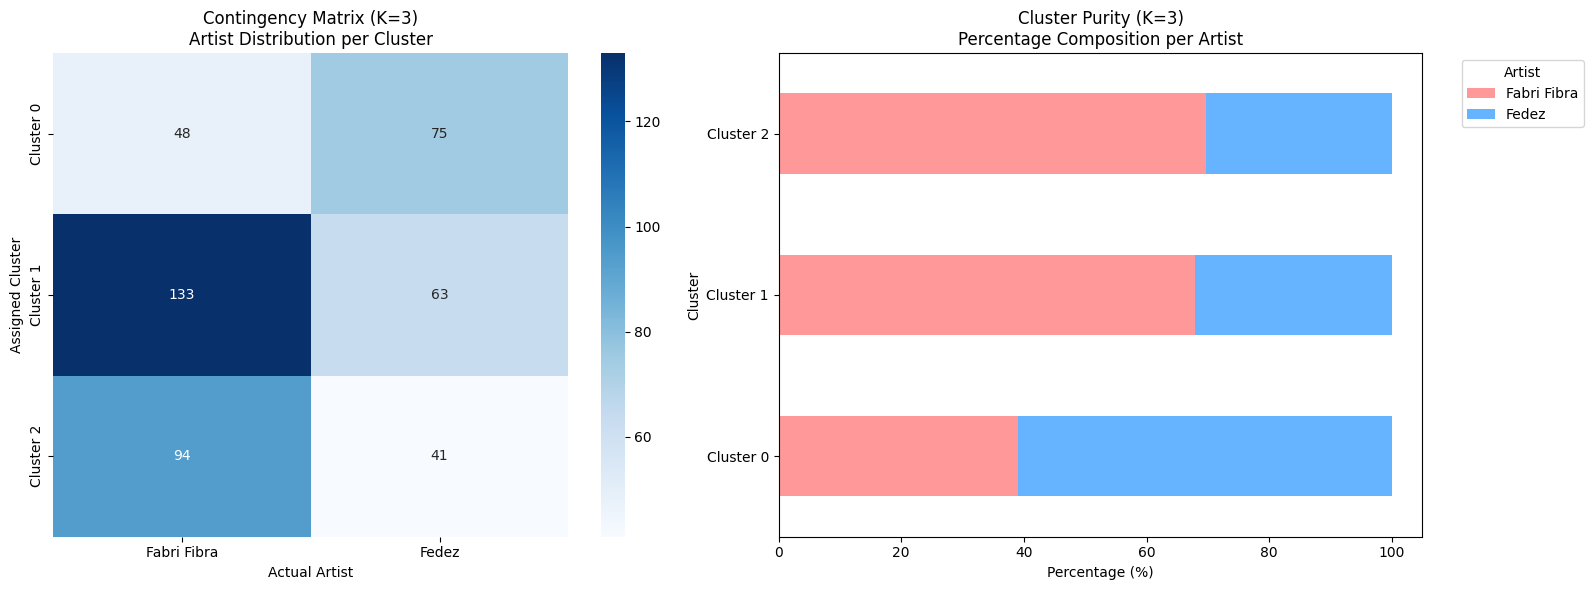

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the artist mapping for readability
ARTIST_MAP = {
    "ART07024718": "Fedez",
    "ART25707984": "Fabri Fibra"
}

# 2. Map the IDs in y_ok to names
artist_names = [ARTIST_MAP.get(name, name) for name in y_ok]

# 3. Create a temporary DataFrame for plotting
plot_df = pd.DataFrame({
    'Cluster': [f'Cluster {c}' for c in cl_dtw],
    'Artist': artist_names
})

# 4. Create the Contingency Matrix
contingency_matrix = pd.crosstab(plot_df['Cluster'], plot_df['Artist'])

# --- Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: Heatmap (Contingency Matrix)
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'Contingency Matrix (K={k_dtw})\nArtist Distribution per Cluster')
ax[0].set_ylabel('Assigned Cluster')
ax[0].set_xlabel('Actual Artist')

# PLOT 2: Percentage Composition (Stacked Bar Chart)
contingency_pct = contingency_matrix.div(contingency_matrix.sum(axis=1), axis=0) * 100
contingency_pct.plot(kind='barh', stacked=True, ax=ax[1], color=['#ff9999','#66b3ff'])
ax[1].set_title(f'Cluster Purity (K={k_dtw})\nPercentage Composition per Artist')
ax[1].set_xlabel('Percentage (%)')
ax[1].set_ylabel('Cluster')
ax[1].legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

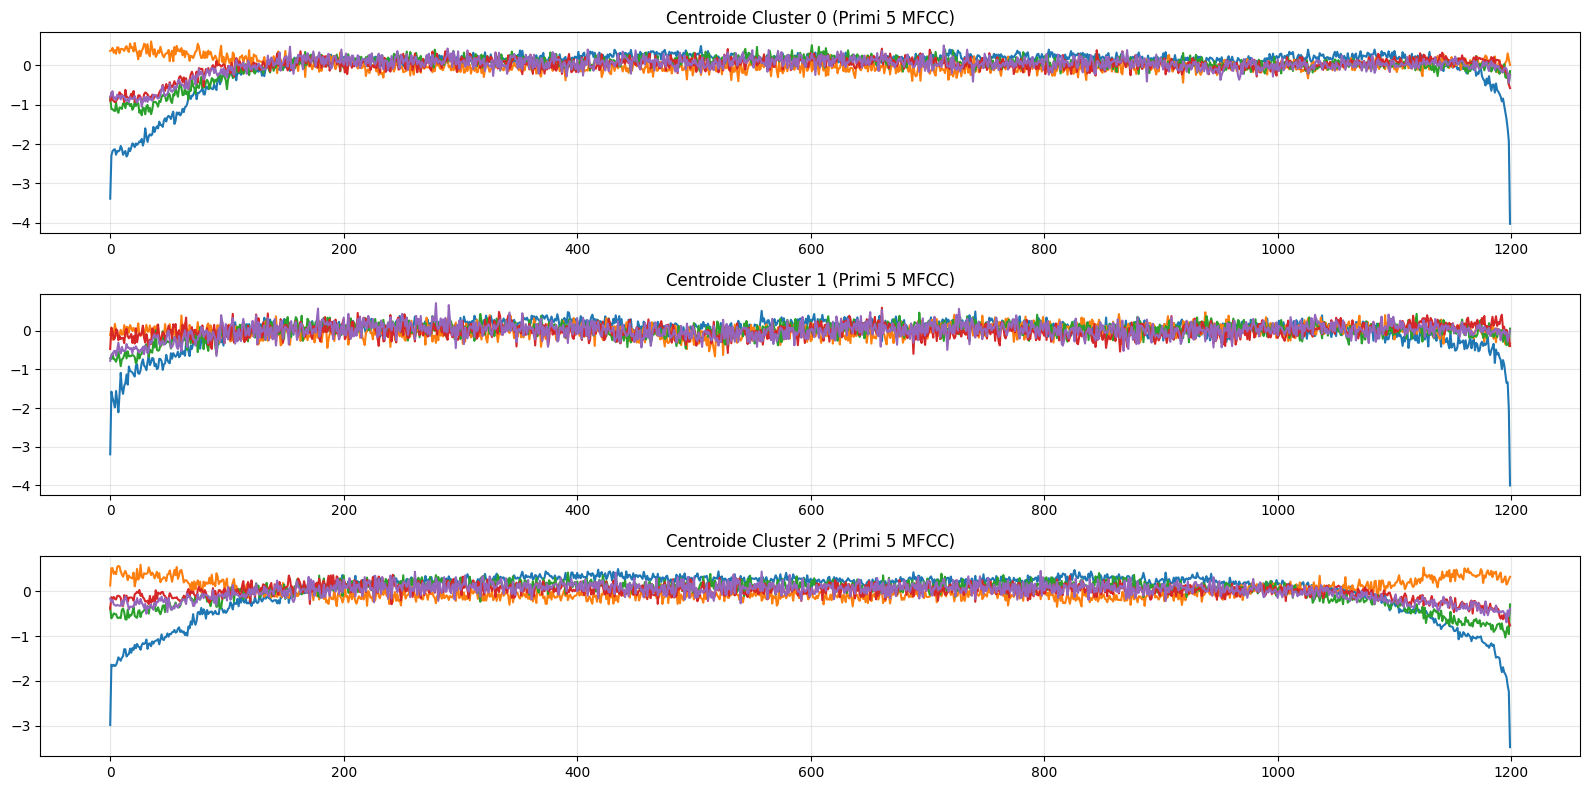

In [20]:
# Visualizzazione dei Centroidi (Serie Temporale Media)
plt.figure(figsize=(16, 8))

# Recuperiamo i centroidi dal modello km_dtw
# Nota: se km_dtw è stato definito dentro il loop, assicurati di usare il modello "best"
# o di rieseguire il fit per il k ottimale.
centroids = km_dtw.cluster_centers_ 

for i in range(k_dtw):
    plt.subplot(k_dtw, 1, i + 1)
    # Mostriamo solo i primi coefficienti MFCC (es. i primi 5) per non sovraffollare
    plt.plot(centroids[i, :, :5]) 
    plt.title(f"Centroide Cluster {i} (Primi 5 MFCC)")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Calcolo matrice di distanza DTW per t-SNE...


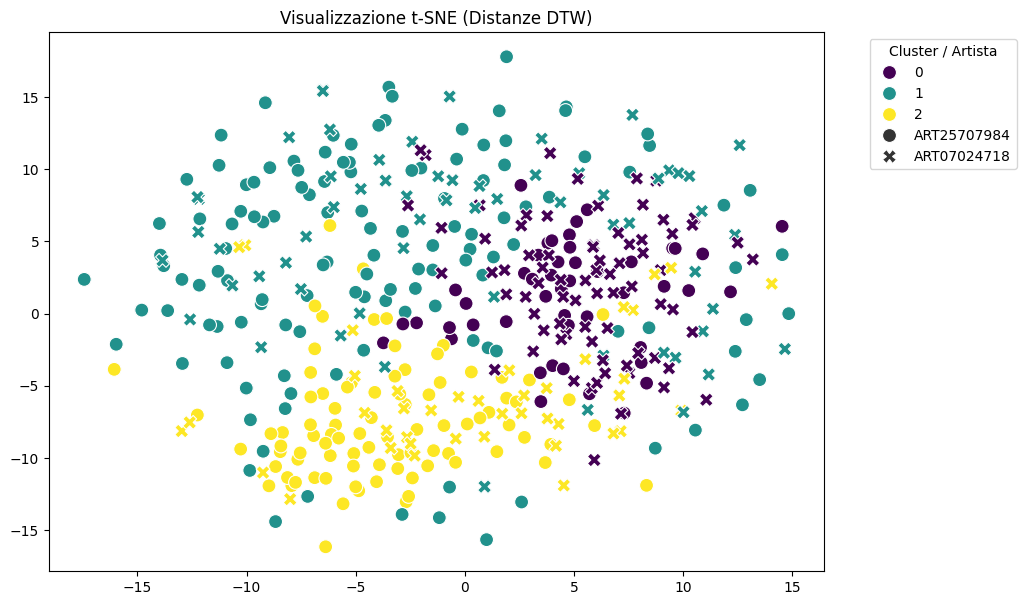

In [22]:
from sklearn.manifold import TSNE
from tslearn.metrics import cdist_dtw

# Attenzione: calcolare la matrice di distanza DTW completa è lento.
# Lo facciamo solo se il dataset non è enorme (454 tracce è ok).
print("Calcolo matrice di distanza DTW per t-SNE...")
dist_matrix = cdist_dtw(X, n_jobs=-1, sakoe_chiba_radius=0.1)

# Applichiamo t-SNE sulla matrice di distanza
tsne = TSNE(n_components=2, metric="precomputed", init="random", random_state=42)
X_embedded = tsne.fit_transform(dist_matrix)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=cl_dtw, style=y_ok, palette='viridis', s=100)
plt.title("Visualizzazione t-SNE (Distanze DTW)")
plt.legend(title="Cluster / Artista", bbox_to_anchor=(1.05, 1))
plt.show()

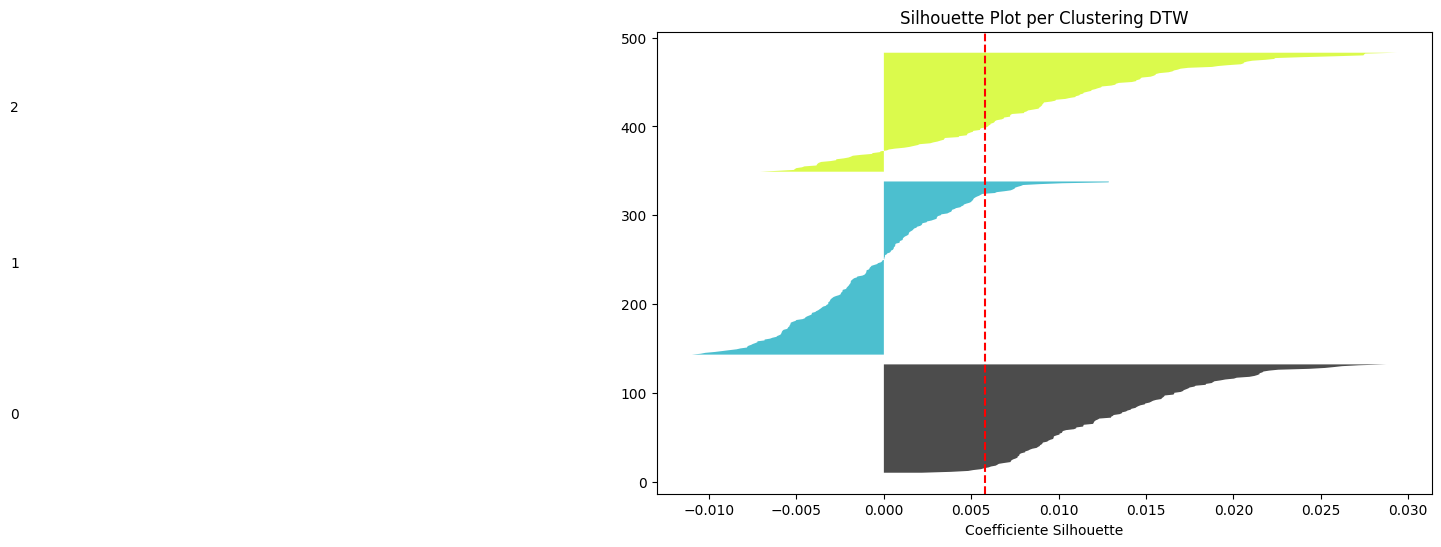

In [23]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# Usiamo la dist_matrix calcolata sopra
sample_silhouette_values = silhouette_samples(dist_matrix, cl_dtw, metric="precomputed")

plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(k_dtw):
    ith_cluster_silhouette_values = sample_silhouette_values[cl_dtw == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / k_dtw)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.title("Silhouette Plot per Clustering DTW")
plt.xlabel("Coefficiente Silhouette")
plt.axvline(x=sample_silhouette_values.mean(), color="red", linestyle="--")
plt.show()

## Euclidian

In [16]:
from tslearn.clustering import TimeSeriesKMeans
import numpy as np

# ---- Configurazione Clustering ----
L_fast = 1200
max_iter = 10
n_init = 1
k_values = range(2, 7)  # k = 2..6

# 1. Preparazione X (già filtrata e scalata nei passaggi precedenti)
X_fast = X # Usiamo la X già processata a L=1200

# 2. Convertiamo temporaneamente le label stringa in numeri per il calcolo della purezza
# Creiamo una mappatura: Fedez -> 0, Fabri Fibra -> 1 (o viceversa in base ai tuoi dati)
unique_artists = sorted(list(set(y_ok)))
artist_to_idx = {name: i for i, name in enumerate(unique_artists)}
y_numeric = np.array([artist_to_idx[name] for name in y_ok])

print(f"Mappatura per calcolo purezza: {artist_to_idx}")

best_k = None
best_score = -1.0
best_cl = None

# ---- Loop di Clustering ----
for k in k_values:
    km_euc = TimeSeriesKMeans(
        n_clusters=k,
        metric="euclidean",
        max_iter=max_iter,
        n_init=n_init,
        random_state=0
    )

    cl = km_euc.fit_predict(X_fast)

    print(f"\n[EUCLIDEAN-KMeans] k={k} completato.")
    
    correct = 0
    for c in range(k):
        idx = (cl == c)
        n_c = int(idx.sum())
        # Usiamo y_numeric per bincount
        counts = np.bincount(y_numeric[idx], minlength=len(unique_artists)) if n_c else np.zeros(len(unique_artists))
        
        # Identifichiamo l'artista dominante nel cluster
        dom_idx = np.argmax(counts)
        dom_name = unique_artists[dom_idx]
        dom_count = int(counts[dom_idx])
        
        purity = dom_count / n_c if n_c else 0.0
        correct += dom_count

        # Stampa dettagliata (adattata dinamicamente agli artisti presenti)
        counts_str = " | ".join([f"{unique_artists[i]}={int(counts[i])}" for i in range(len(unique_artists))])
        print(f"  - Cluster {c}: n={n_c} | {counts_str} | dominante={dom_name} | purity={purity:.3f}")

    overall_purity = correct / len(cl) if len(cl) else 0.0
    print(f"Purity totale per k={k}: {overall_purity:.3f}")

    if overall_purity > best_score:
        best_score = overall_purity
        best_k = k
        best_cl = cl

print(f"\n[RISULTATO] Miglior k: {best_k} con purezza={best_score:.3f}")

# Variabili finali pronte per l'uso
cl_eu = best_cl
k_eu = best_k

Mappatura per calcolo purezza: {'ART07024718': 0, 'ART25707984': 1}

[EUCLIDEAN-KMeans] k=2 completato.
  - Cluster 0: n=134 | ART07024718=35 | ART25707984=99 | dominante=ART25707984 | purity=0.739
  - Cluster 1: n=320 | ART07024718=144 | ART25707984=176 | dominante=ART25707984 | purity=0.550
Purity totale per k=2: 0.606

[EUCLIDEAN-KMeans] k=3 completato.
  - Cluster 0: n=90 | ART07024718=18 | ART25707984=72 | dominante=ART25707984 | purity=0.800
  - Cluster 1: n=239 | ART07024718=121 | ART25707984=118 | dominante=ART07024718 | purity=0.506
  - Cluster 2: n=125 | ART07024718=40 | ART25707984=85 | dominante=ART25707984 | purity=0.680
Purity totale per k=3: 0.612

[EUCLIDEAN-KMeans] k=4 completato.
  - Cluster 0: n=89 | ART07024718=18 | ART25707984=71 | dominante=ART25707984 | purity=0.798
  - Cluster 1: n=242 | ART07024718=119 | ART25707984=123 | dominante=ART25707984 | purity=0.508
  - Cluster 2: n=81 | ART07024718=27 | ART25707984=54 | dominante=ART25707984 | purity=0.667
  - Cluster

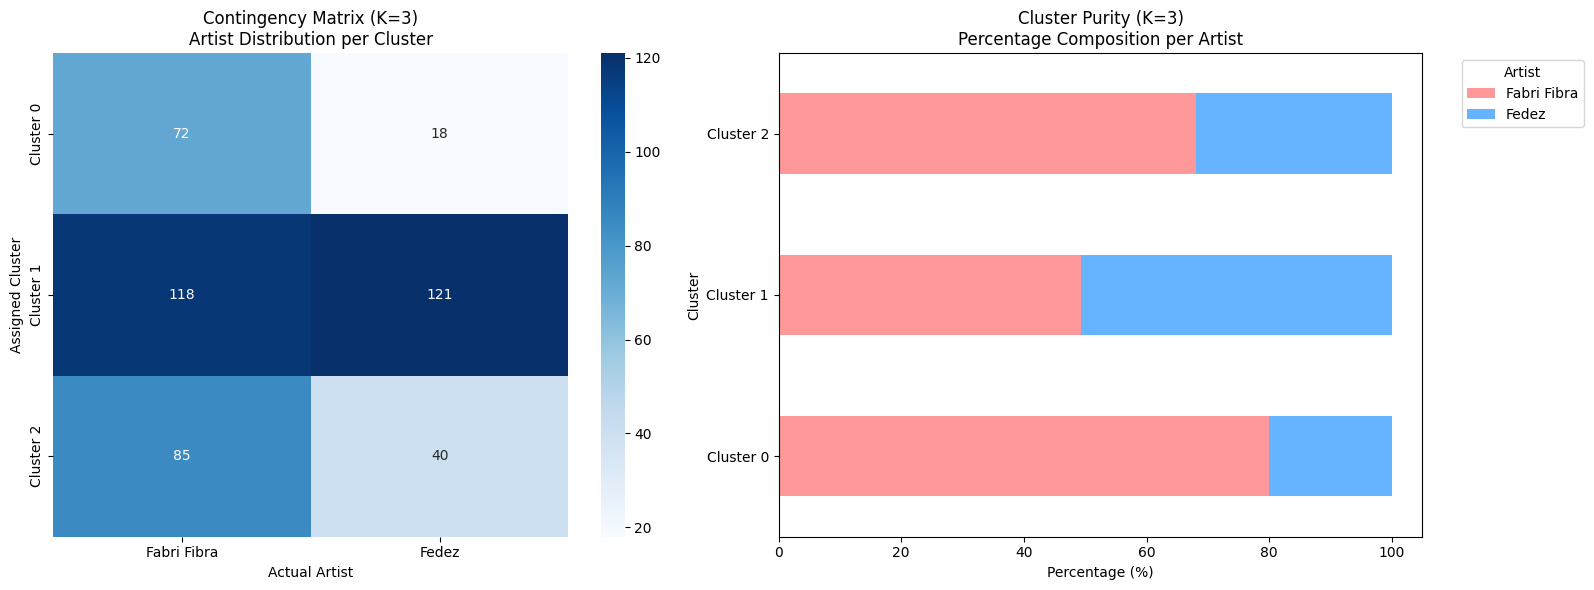

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the artist mapping for readability
ARTIST_MAP = {
    "ART07024718": "Fedez",
    "ART25707984": "Fabri Fibra"
}

# 2. Map the IDs in y_ok to names
artist_names = [ARTIST_MAP.get(name, name) for name in y_ok]

# 3. Create a temporary DataFrame for plotting
plot_df = pd.DataFrame({
    'Cluster': [f'Cluster {c}' for c in cl_eu],
    'Artist': artist_names
})

# 4. Create the Contingency Matrix
contingency_matrix = pd.crosstab(plot_df['Cluster'], plot_df['Artist'])

# --- Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: Heatmap (Contingency Matrix)
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'Contingency Matrix (K={k_eu})\nArtist Distribution per Cluster')
ax[0].set_ylabel('Assigned Cluster')
ax[0].set_xlabel('Actual Artist')

# PLOT 2: Percentage Composition (Stacked Bar Chart)
contingency_pct = contingency_matrix.div(contingency_matrix.sum(axis=1), axis=0) * 100
contingency_pct.plot(kind='barh', stacked=True, ax=ax[1], color=['#ff9999','#66b3ff'])
ax[1].set_title(f'Cluster Purity (K={k_eu})\nPercentage Composition per Artist')
ax[1].set_xlabel('Percentage (%)')
ax[1].set_ylabel('Cluster')
ax[1].legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [21]:
# 1. Create df_analysis from your processed dataframe
df_analysis = df_processed.copy()

# 2. ATTACH the cluster labels (This solves the KeyError)
df_analysis['cluster_id'] = cl_eu

# 3. Map the Artist IDs to English names for better readability
ARTIST_MAP = {
    "ART07024718": "Fedez",
    "ART25707984": "Fabri Fibra"
}
df_analysis['artist_name'] = df_analysis['id_artist'].map(ARTIST_MAP)

# 4. Filter only tracks belonging to Cluster 1
cluster_1_tracks = df_analysis[df_analysis['cluster_id'] == 1].copy()

print(f"Total tracks in Cluster 1: {len(cluster_1_tracks)}")
print(cluster_1_tracks['artist_name'].value_counts())

Total tracks in Cluster 1: 239
artist_name
Fedez          121
Fabri Fibra    118
Name: count, dtype: int64


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

# Flatten X (Time Series) to compare the 'audio fingerprint'
# X shape (N, 1200, 20) -> (N, 24000)
X_flat = X.reshape(X.shape[0], -1)

# Get the indices of tracks that are in Cluster 1
c1_indices = cluster_1_tracks.index.tolist()
X_c1 = X_flat[c1_indices]

# Calculate similarity only for Cluster 1
sim_matrix_c1 = cosine_similarity(X_c1)

c1_titles = cluster_1_tracks['title'].values
c1_artists = cluster_1_tracks['artist_name'].values

cross_sim_results = []

# Loop through pairs to find cross-artist similarities
for i in range(len(c1_titles)):
    for j in range(i + 1, len(c1_titles)):
        if c1_artists[i] != c1_artists[j]:
            cross_sim_results.append({
                'song_A': c1_titles[i],
                'artist_A': c1_artists[i],
                'song_B': c1_titles[j],
                'artist_B': c1_artists[j],
                'similarity': sim_matrix_c1[i, j]
            })

# Display top 10 "Twins" (Songs that sound nearly identical across artists)
df_twins = pd.DataFrame(cross_sim_results).sort_values(by='similarity', ascending=False)
df_twins.head(10)

,song_A,artist_A,song_B,artist_B,similarity
14038,Qui Dentro,Fabri Fibra,Che cazzo ridi,Fedez,0.166726
869,Noia,Fabri Fibra,BELLA STRONZA,Fedez,0.160168
5111,El Diablo,Fabri Fibra,MI STO SUL CAZZO,Fedez,0.154829
14090,Qui Dentro,Fabri Fibra,Nel mio piccolo,Fedez,0.148300
14058,Qui Dentro,Fabri Fibra,BELLA STRONZA,Fedez,0.146243
8780,Meglio Me Che Te,Fabri Fibra,Olivia Oil,Fedez,0.145632
944,Noia,Fabri Fibra,Cambia,Fedez,0.140320
5113,El Diablo,Fabri Fibra,FEDE E SPERANZA,Fedez,0.138234
10464,Tutti In Campana,Fabri Fibra,Segni,Fedez,0.137964
12521,Tutti In Quarantena (Coronavirus Freestyle),Fabri Fibra,Segni,Fedez,0.137817


In [24]:
# Invece di appiattire tutto (1200*20), calcoliamo la media dei MFCC nel tempo
# Questo trasforma ogni canzone in un profilo medio di 20 valori
X_c1_avg = X[c1_indices].mean(axis=1) # Shape: (N_cluster_1, 20)

# Ora calcoliamo la similarità su questi profili medi
sim_matrix_avg = cosine_similarity(X_c1_avg)

# Ricostruiamo la lista dei "twins"
cross_sim_avg = []
for i in range(len(c1_titles)):
    for j in range(i + 1, len(c1_titles)):
        if c1_artists[i] != c1_artists[j]:
            cross_sim_avg.append({
                'song_A': c1_titles[i],
                'artist_A': c1_artists[i],
                'song_B': c1_titles[j],
                'artist_B': c1_artists[j],
                'similarity': sim_matrix_avg[i, j]
            })

df_twins_avg = pd.DataFrame(cross_sim_avg).sort_values(by='similarity', ascending=False)
print("Nuova similarità basata su profili medi (Cluster 1):")
print(df_twins_avg.head(10))

Nuova similarità basata su profili medi (Cluster 1):
                  song_A     artist_A           song_B artist_B    similarity
4365              Liberi  Fabri Fibra       Cigno nero    Fedez  7.893760e-14
849                 Noia  Fabri Fibra   Che cazzo ridi    Fedez  7.671362e-14
1869             Playboy  Fabri Fibra  Nel mio piccolo    Fedez  6.727754e-14
6930   Quentin Tarantino  Fabri Fibra   SCELTE STUPIDE    Fedez  6.252890e-14
1837             Playboy  Fabri Fibra    BELLA STRONZA    Fedez  6.242966e-14
5875                6791  Fabri Fibra    Cardinal chic    Fedez  6.185476e-14
10581        Raggi Laser  Fabri Fibra  Nel mio piccolo    Fedez  6.038202e-14
7850    Intro (Fenomeno)  Fabri Fibra     Real Randagi    Fedez  6.022445e-14
4402              Liberi  Fabri Fibra             Così    Fedez  5.936582e-14
7766    Intro (Fenomeno)  Fabri Fibra    BELLA STRONZA    Fedez  5.925916e-14


In [25]:
# 1. Calcoliamo la "firma sonora" usando la deviazione standard (texture del suono)
# Invece di .mean(), usiamo .std() che non è influenzato dallo scaler a zero
X_c1_std = X[c1_indices].std(axis=1) 

# 2. Calcolo della similarità
sim_matrix_std = cosine_similarity(X_c1_std)

# 3. Estrazione dei Cross-Artist Twins
cross_sim_std = []
for i in range(len(c1_titles)):
    for j in range(i + 1, len(c1_titles)):
        if c1_artists[i] != c1_artists[j]:
            cross_sim_std.append({
                'song_A': c1_titles[i],
                'artist_A': c1_artists[i],
                'song_B': c1_titles[j],
                'artist_B': c1_artists[j],
                'similarity': sim_matrix_std[i, j]
            })

df_twins_std = pd.DataFrame(cross_sim_std).sort_values(by='similarity', ascending=False)
print("Similarità basata sulla 'Firma Energetica' (Cluster 1):")
print(df_twins_std.head(10))

Similarità basata sulla 'Firma Energetica' (Cluster 1):
                      song_A     artist_A                            song_B  \
4656        Bisogna Scrivere  Fabri Fibra                             Segni   
421      Non fare la puttana  Fabri Fibra                             Segni   
2313              Come Vasco  Fabri Fibra              LA CASSA SPINGE 2021   
9149        Rompiti Il Collo  Fabri Fibra  Vivere in campagna pubblicitaria   
9156        Rompiti Il Collo  Fabri Fibra                            Giorni   
7510               Tony Hawk  Fabri Fibra                            SAPORE   
9162        Rompiti Il Collo  Fabri Fibra                       Ninna nanna   
11402    Il Mio Amico Arnold  Fabri Fibra              LE MADRI DEGLI ALTRI   
6441   Cento Modi Per Morire  Fabri Fibra              LE MADRI DEGLI ALTRI   
951                     Noia  Fabri Fibra                Intro (Pat-a-Cake)   

      artist_B  similarity  
4656     Fedez         1.0  
421      Fedez  

## Add audio cols

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# 1. Create a copy of the processed DataFrame
df_analysis = df_processed.copy()

# 2. ATTACH the cluster labels to the DataFrame
# This step fixes the KeyError by creating the 'cluster_id' column
df_analysis['cluster_id'] = cl_eu

# 3. Define the Artist Mapping and metadata columns
ARTIST_MAP = {
    "ART07024718": "Fedez",
    "ART25707984": "Fabri Fibra"
}
df_analysis['artist_name'] = df_analysis['id_artist'].map(ARTIST_MAP)

# List of numeric audio columns to analyze
AUDIO_COLS = [
    'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'flatness', 
    'spectral_complexity', 'pitch', 'duration_ms', 'popularity'
]

# 4. Filter for Cluster 1 (The low-purity/shared style cluster)
df_c1 = df_analysis[df_analysis['cluster_id'] == 1].copy()

print(f"Cluster 1 isolated: {len(df_c1)} tracks found.")

Cluster 1 isolated: 239 tracks found.


In [28]:
# 1. Normalize the metadata features (Min-Max Scaling)
# We handle non-numeric data and fill missing values with 0
scaler = MinMaxScaler()
features_meta = df_c1[AUDIO_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)
features_scaled = scaler.fit_transform(features_meta)

# 2. Calculate the Cosine Similarity Matrix
sim_matrix_meta = cosine_similarity(features_scaled)

# 3. Identify Top Cross-Artist "Twins" in Cluster 1
c1_titles = df_c1['title'].values
c1_artists = df_c1['artist_name'].values
c1_ids = df_c1['track_id'].values

meta_sim_list = []
for i in range(len(c1_titles)):
    for j in range(i + 1, len(c1_titles)):
        if c1_artists[i] != c1_artists[j]: # Cross-artist only
            meta_sim_list.append({
                'id_1': c1_ids[i],
                'song_1': c1_titles[i],
                'artist_1': c1_artists[i],
                'id_2': c1_ids[j],
                'song_2': c1_titles[j],
                'artist_2': c1_artists[j],
                'metadata_similarity': sim_matrix_meta[i, j]
            })

# 4. Create the final results DataFrame
df_meta_twins = pd.DataFrame(meta_sim_list).sort_values(by='metadata_similarity', ascending=False)

print("Top 10 Most Similar Cross-Artist Tracks in Cluster 1 (Audio Metadata):")
df_meta_twins.head(10)

Top 10 Most Similar Cross-Artist Tracks in Cluster 1 (Audio Metadata):


,id_1,song_1,artist_1,id_2,song_2,artist_2,metadata_similarity
7562,TR700280,Tony Hawk,Fabri Fibra,TR943904,Cosa senza spine,Fedez,0.995619
6957,TR835623,Quentin Tarantino,Fabri Fibra,TR943904,Cosa senza spine,Fedez,0.994171
11677,TR731271,Mani Pulite,Fabri Fibra,TR552809,Psichedelico,Fedez,0.993947
2094,TR307915,A Me Di Te,Fabri Fibra,TR897360,Polaroid,Fedez,0.993583
5364,TR844218,A Volte,Fabri Fibra,TR731379,Record,Fedez,0.993456
5275,TR895785,Mi Stai Sul Cazzo,Fabri Fibra,TR625764,Ti vorrei dire,Fedez,0.993370
9833,TR709968,Nemico Pubblico,Fabri Fibra,TR622333,Penisola che non c’è,Fedez,0.993232
3940,TR167740,Dipinto di blu,Fabri Fibra,TR511007,Olivia Oil,Fedez,0.993127
770,TR998998,Come Mai,Fabri Fibra,TR845385,CRISI DI STATO,Fedez,0.993095
10683,TR547400,La Fretta,Fabri Fibra,TR627217,FUORI DAI GUAI,Fedez,0.992910


## Motif and anomalies analysis

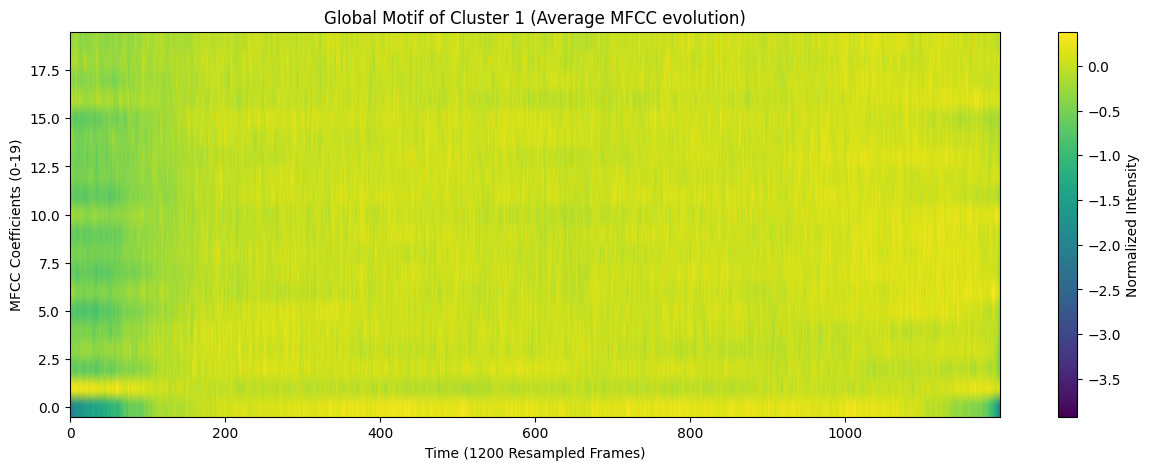

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify the centroid of Cluster 1
# If you used km_euc in your previous cell:
centroid_1 = km_euc.cluster_centers_[1] 

# 2. Visualize the Temporal Motif (Average MFCC path)
plt.figure(figsize=(15, 5))
plt.imshow(centroid_1.T, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Normalized Intensity')
plt.title("Global Motif of Cluster 1 (Average MFCC evolution)")
plt.xlabel("Time (1200 Resampled Frames)")
plt.ylabel("MFCC Coefficients (0-19)")
plt.show()

In [30]:
from sklearn.metrics import pairwise_distances_argmin_min

# 1. Isolate MFCCs for tracks in Cluster 1
c1_indices = df_analysis[df_analysis['cluster_id'] == 1].index.tolist()
X_c1 = X[c1_indices]

# 2. Find the track closest to the centroid (The Medoid)
# We flatten X_c1 and the centroid for distance calculation
X_c1_flat = X_c1.reshape(len(X_c1), -1)
centroid_flat = centroid_1.flatten().reshape(1, -1)

closest_idx, _ = pairwise_distances_argmin_min(centroid_flat, X_c1_flat)
proto_track_idx = c1_indices[closest_idx[0]]

# 3. Retrieve the "Motif Leader"
proto_track = df_analysis.loc[proto_track_idx]
print(f"The 'Prototypical Motif' of Cluster 1 is represented by:")
print(f"Artist: {proto_track['artist_name']} | Song: {proto_track['title']}")

The 'Prototypical Motif' of Cluster 1 is represented by:
Artist: Fabri Fibra | Song: Tutti In Quarantena (Coronavirus Freestyle)


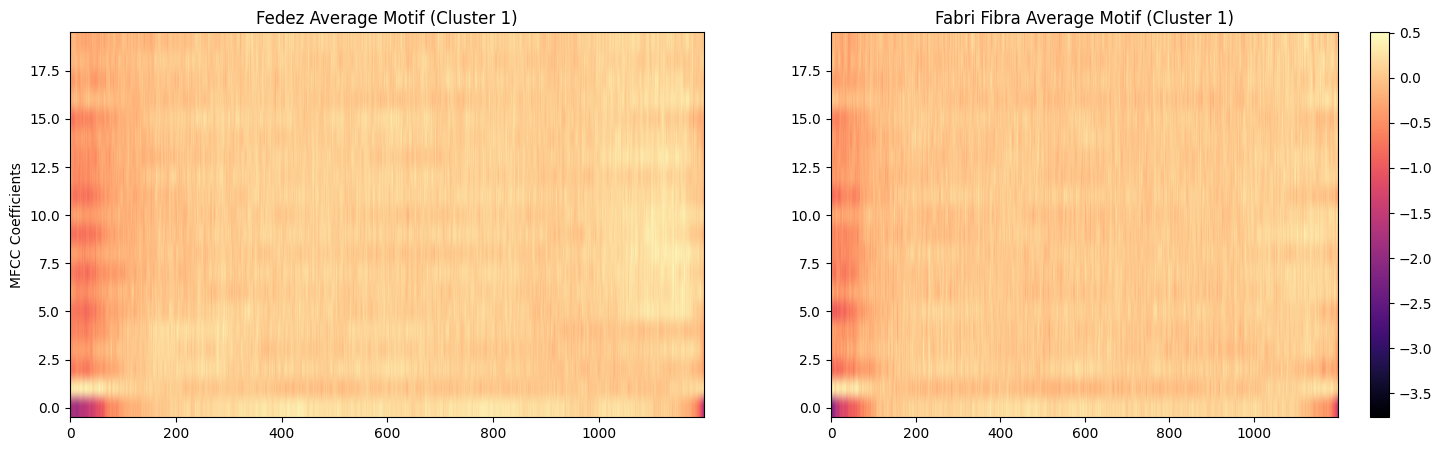

In [31]:
# Separate tracks by artist within Cluster 1
fedez_c1 = X[df_analysis[(df_analysis['cluster_id'] == 1) & (df_analysis['artist_name'] == 'Fedez')].index]
fibra_c1 = X[df_analysis[(df_analysis['cluster_id'] == 1) & (df_analysis['artist_name'] == 'Fabri Fibra')].index]

# Calculate the mean motif for each artist in this cluster
motif_fedez = fedez_c1.mean(axis=0)
motif_fibra = fibra_c1.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

im1 = ax1.imshow(motif_fedez.T, aspect='auto', origin='lower', cmap='magma')
ax1.set_title("Fedez Average Motif (Cluster 1)")
ax1.set_ylabel("MFCC Coefficients")

im2 = ax2.imshow(motif_fibra.T, aspect='auto', origin='lower', cmap='magma')
ax2.set_title("Fabri Fibra Average Motif (Cluster 1)")

plt.colorbar(im2, ax=ax2)
plt.show()

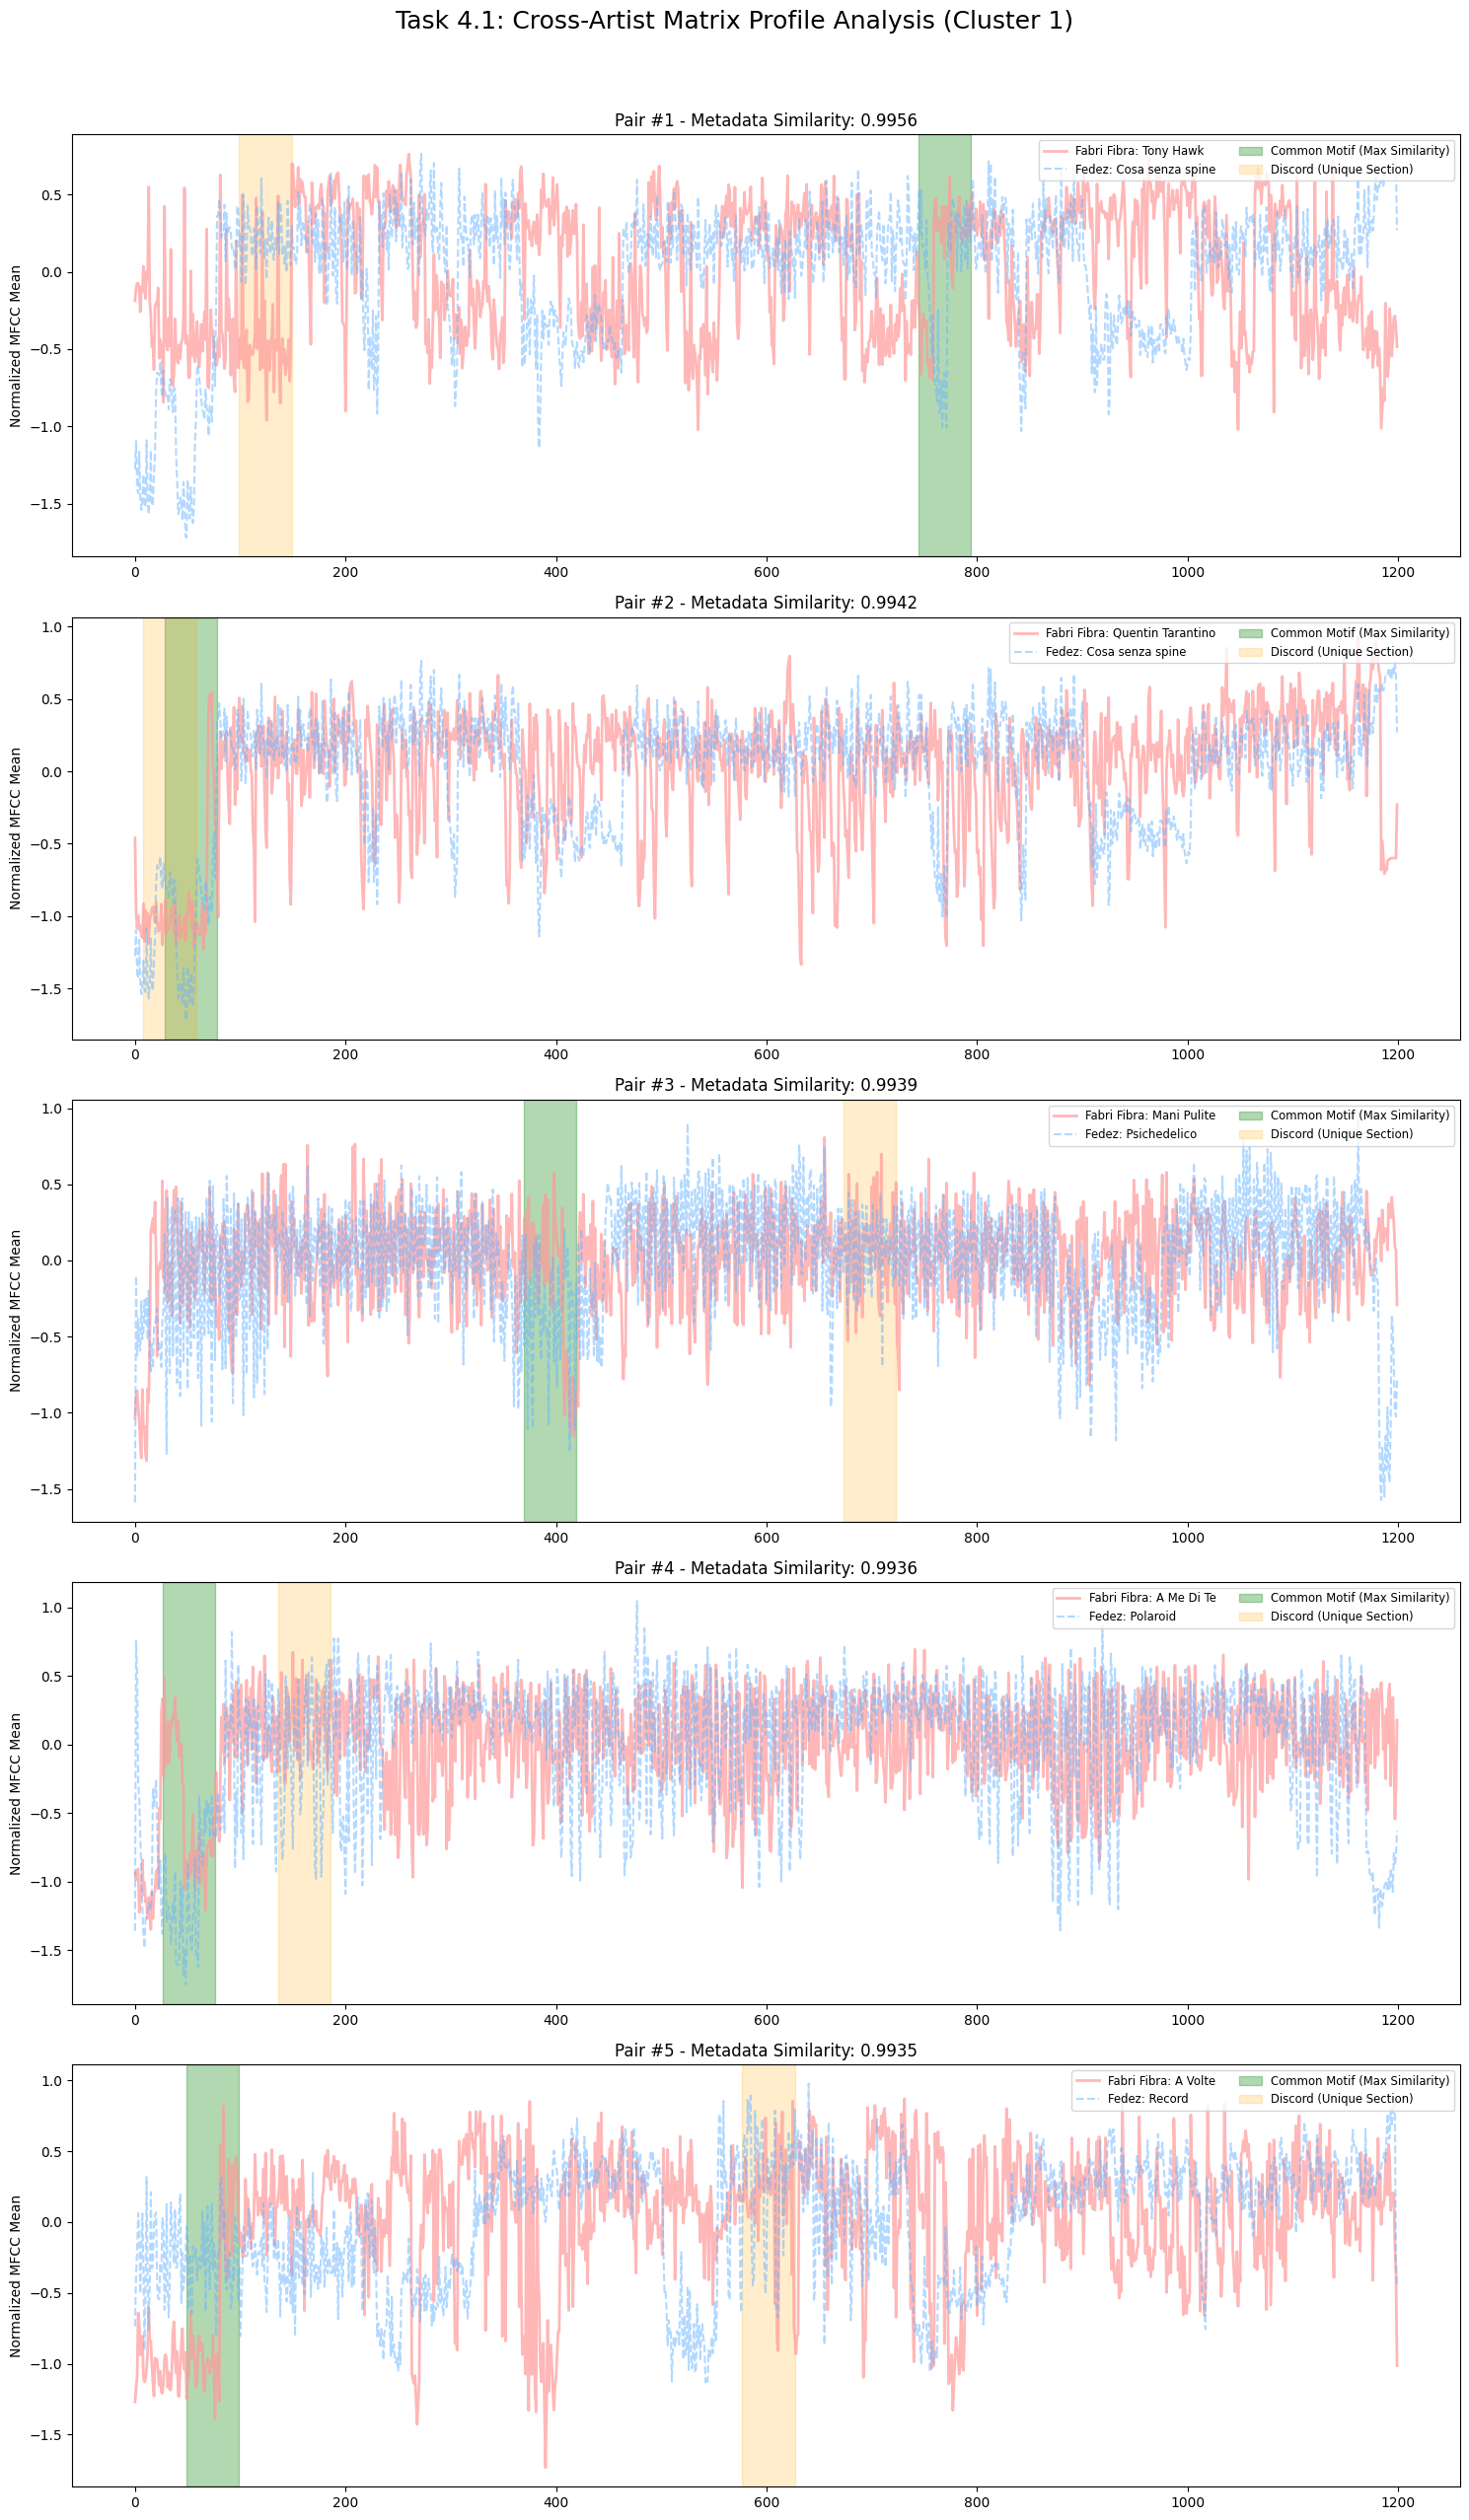

In [32]:
import stumpy
import numpy as np
import matplotlib.pyplot as plt

# 1. Select the top 5 matches from the Cluster 1 twins analysis
# We ensure we are using the pairs we found in the neutral cluster
top_matches = df_meta_twins.head(5)

m = 50 # Window size (roughly 1.1 - 2 seconds depending on your hop_length)

fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Task 4.1: Cross-Artist Matrix Profile Analysis (Cluster 1)', fontsize=18, y=1.02)

# Ensure X is float64 for stumpy (it can be picky with float32)
X_stump = X.astype(np.float64)

for i, (index, row) in enumerate(top_matches.iterrows()):
    # Find the numeric index in the X matrix for both songs
    # We use the index from the metadata dataframe to match the X matrix rows
    idx_a = df_analysis[df_analysis['track_id'] == row['id_1']].index[0]
    idx_b = df_analysis[df_analysis['track_id'] == row['id_2']].index[0]
    
    # Extract the signal: averaging the 20 MFCCs to create a 1D "Timbre Stream"
    s_a = X_stump[idx_a, :, :].mean(axis=1)
    s_b = X_stump[idx_b, :, :].mean(axis=1)
    
    # 2. CALCULATE CROSS-MATRIX PROFILE
    # This finds segments in Song A (Fedez) that are most similar to Song B (Fibra)
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b, ignore_trivial=False)
    
    # Motif: The point of lowest distance (maximum similarity)
    idx_a_motif = np.argmin(comp_mp[:, 0])
    # Discord: The point of highest distance (maximum anomaly relative to the other artist)
    idx_a_discord = np.argmax(comp_mp[:, 0])
    
    # 3. VISUALIZATION
    ax = axes[i]
    ax.plot(s_a, label=f"{row['artist_1']}: {row['song_1']}", color='#ff9999', alpha=0.7, lw=2)
    ax.plot(s_b, label=f"{row['artist_2']}: {row['song_2']}", color='#66b3ff', linestyle='--', alpha=0.5)
    
    # Highlight Common Motif (Green)
    ax.axvspan(idx_a_motif, idx_a_motif + m, color='green', alpha=0.3, label='Common Motif (Max Similarity)')
    
    # Highlight Discord (Orange)
    ax.axvspan(idx_a_discord, idx_a_discord + m, color='orange', alpha=0.2, label='Discord (Unique Section)')
    
    ax.set_title(f"Pair #{i+1} - Metadata Similarity: {row['metadata_similarity']:.4f}")
    ax.set_ylabel("Normalized MFCC Mean")
    ax.legend(loc='upper right', fontsize='small', ncol=2)

plt.tight_layout()
plt.show()

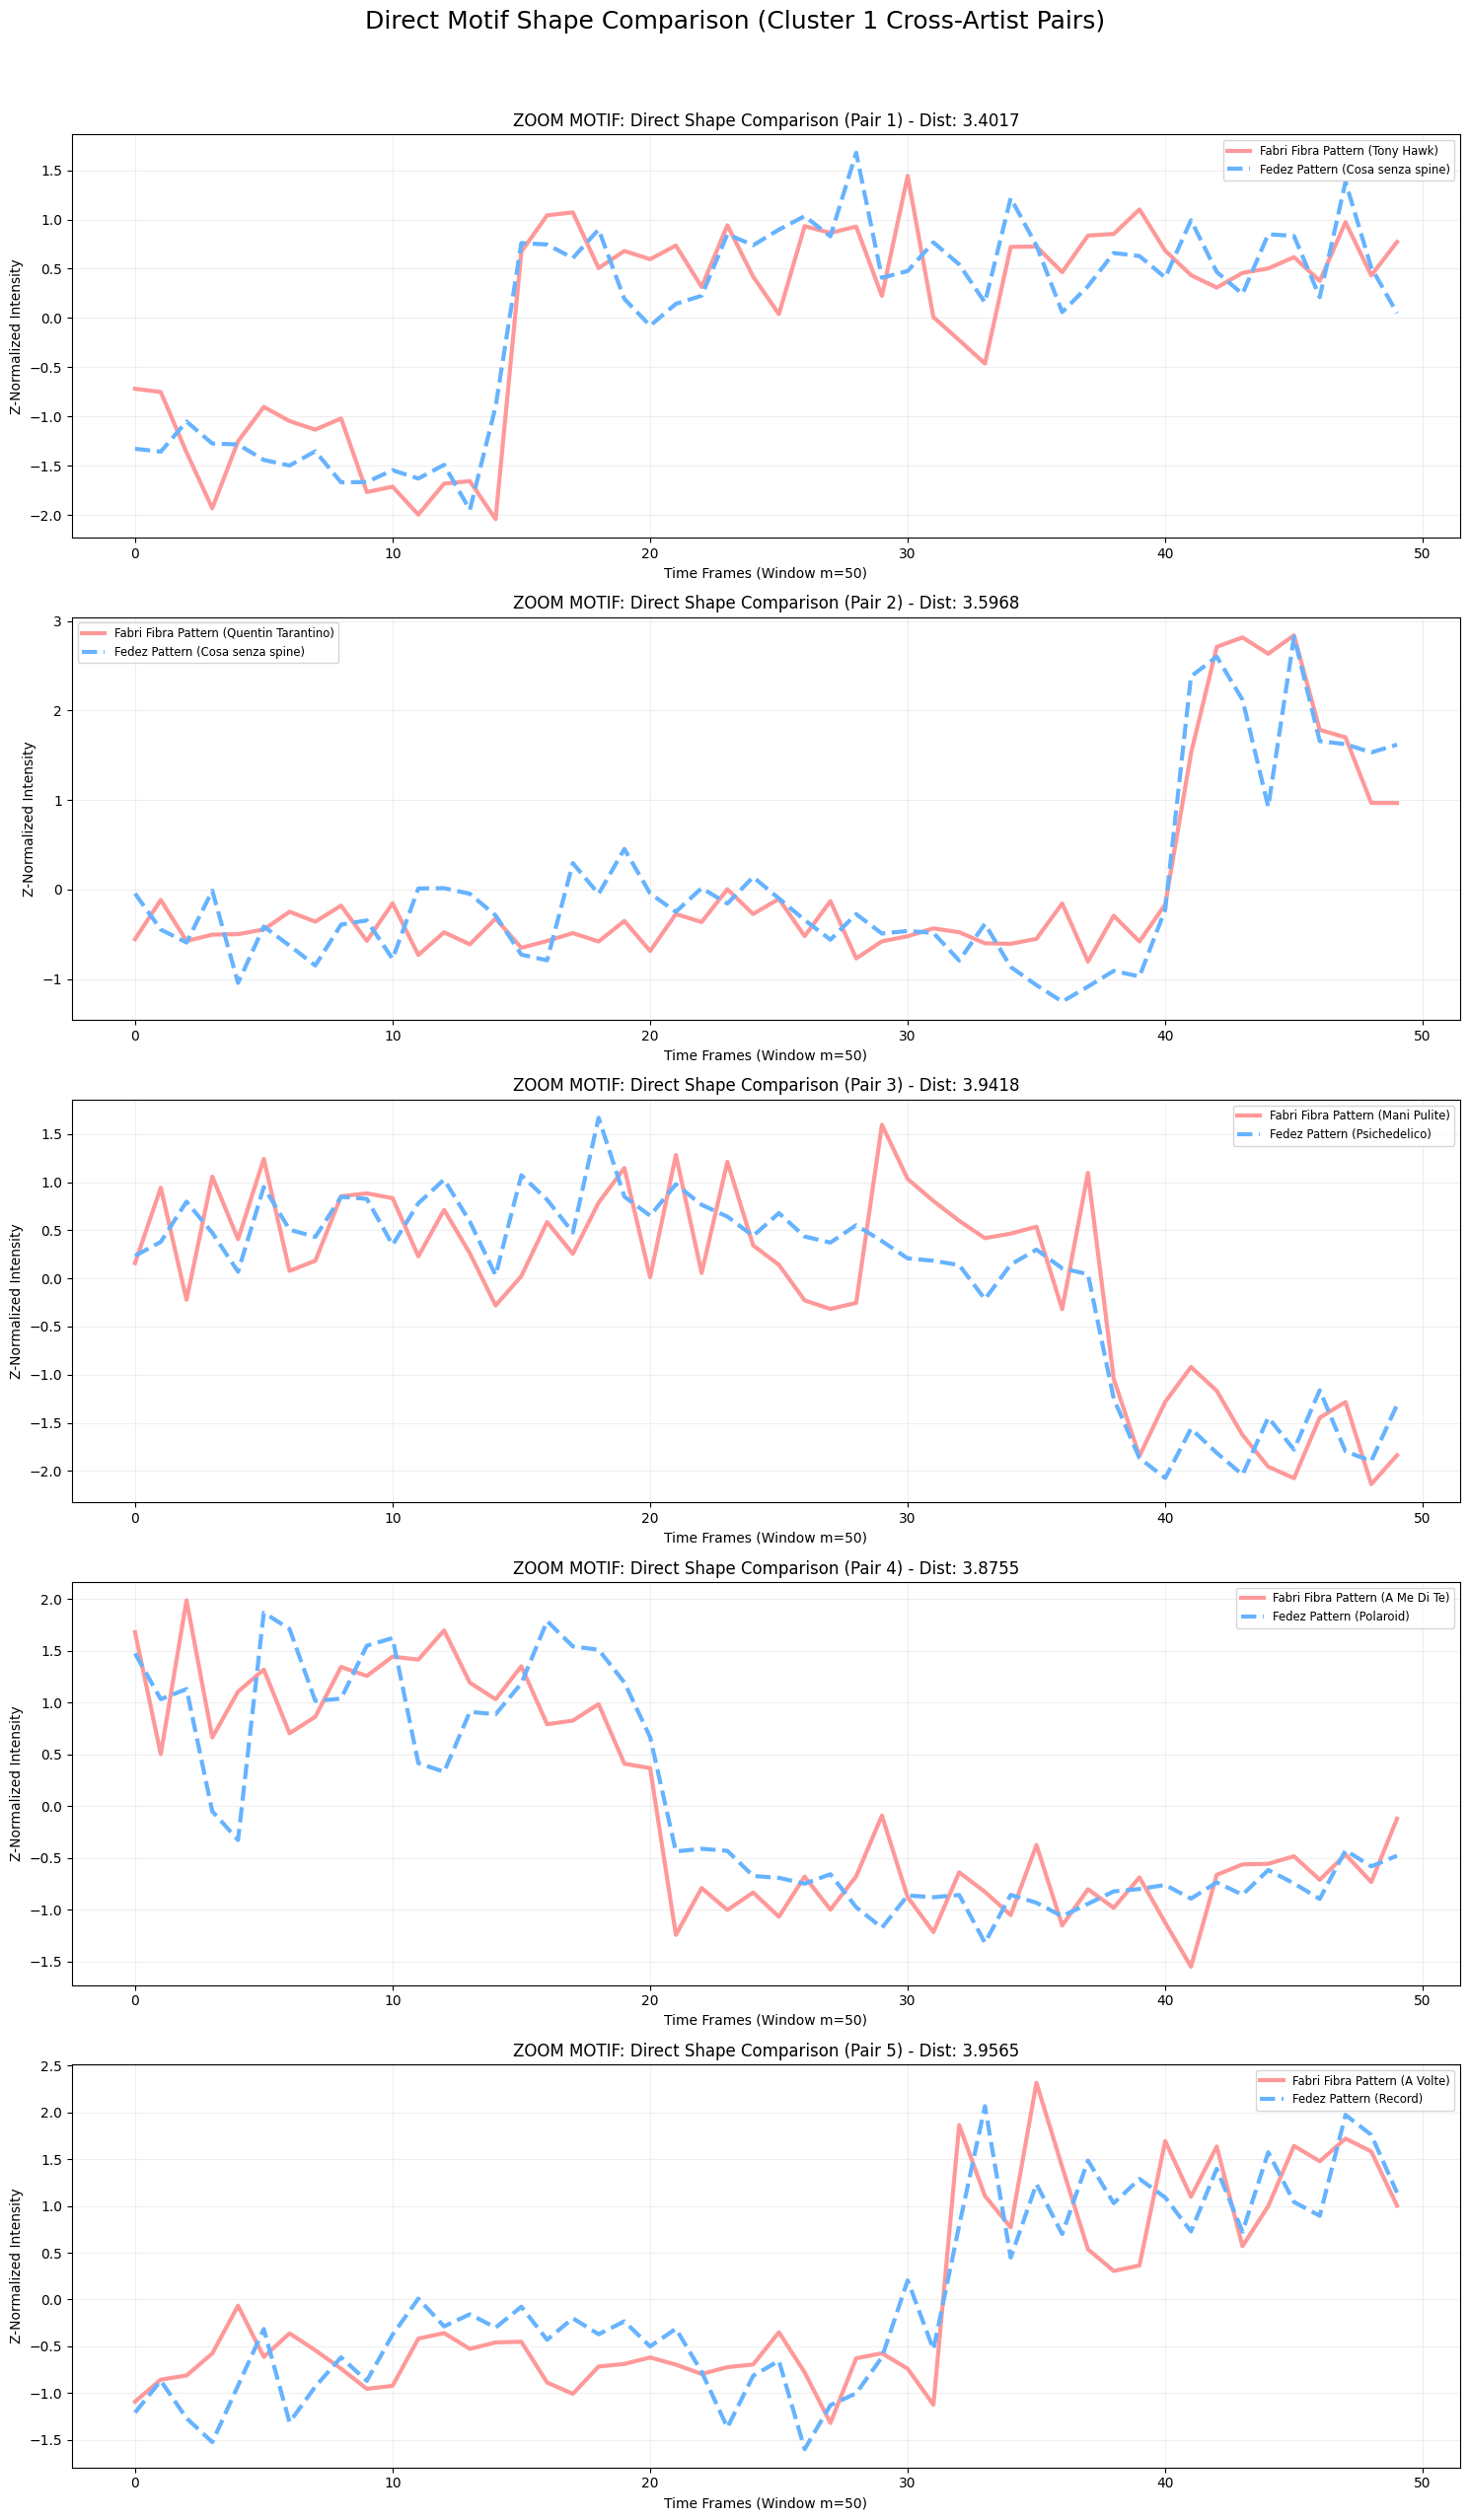

In [33]:
import stumpy
import numpy as np
import matplotlib.pyplot as plt

# Using m=50 (approx. 1-2 seconds) to find local patterns
m = 50 
fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Direct Motif Shape Comparison (Cluster 1 Cross-Artist Pairs)', fontsize=18, y=1.02)

# Use the top 5 matches from your metadata twins analysis
for i, (index, row) in enumerate(df_meta_twins.head(5).iterrows()):
    # 1. Retrieve indices for the X matrix
    idx_a = df_analysis[df_analysis['track_id'] == row['id_1']].index[0]
    idx_b = df_analysis[df_analysis['track_id'] == row['id_2']].index[0]
    
    # 2. Extract 1D Time Series (Averaged MFCCs)
    # Ensure float64 for stumpy stability
    s_a = X[idx_a, :, :].mean(axis=1).flatten().astype(float)
    s_b = X[idx_b, :, :].mean(axis=1).flatten().astype(float)
    
    # 3. Calculate Matrix Profile Join (Compare s_a to s_b)
    # This finds the best match for every subsequence in A within B
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b, ignore_trivial=False)
    
    # Identify the starting index of the best motif in A and its match in B
    idx_a_motif = np.argmin(comp_mp[:, 0])
    idx_b_motif = comp_mp[idx_a_motif, 1]
    
    # 4. Extract and Z-Normalize segments to compare SHAPE only
    segment_a = s_a[idx_a_motif : idx_a_motif + m]
    segment_b = s_b[idx_b_motif : idx_b_motif + m]
    
    # Normalization (Standardization) handles different scales
    segment_a_std = (segment_a - np.mean(segment_a)) / np.std(segment_a)
    segment_b_std = (segment_b - np.mean(segment_b)) / np.std(segment_b)
    
    # 5. Plotting
    ax = axes[i]
    ax.plot(segment_a_std, label=f"{row['artist_1']} Pattern ({row['song_1']})", lw=3, color='#ff9999')
    ax.plot(segment_b_std, label=f"{row['artist_2']} Pattern ({row['song_2']})", lw=3, color='#66b3ff', linestyle='--')
    
    ax.set_title(f"ZOOM MOTIF: Direct Shape Comparison (Pair {i+1}) - Dist: {np.min(comp_mp[:, 0]):.4f}")
    ax.set_xlabel("Time Frames (Window m=50)")
    ax.set_ylabel("Z-Normalized Intensity")
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Anomalies

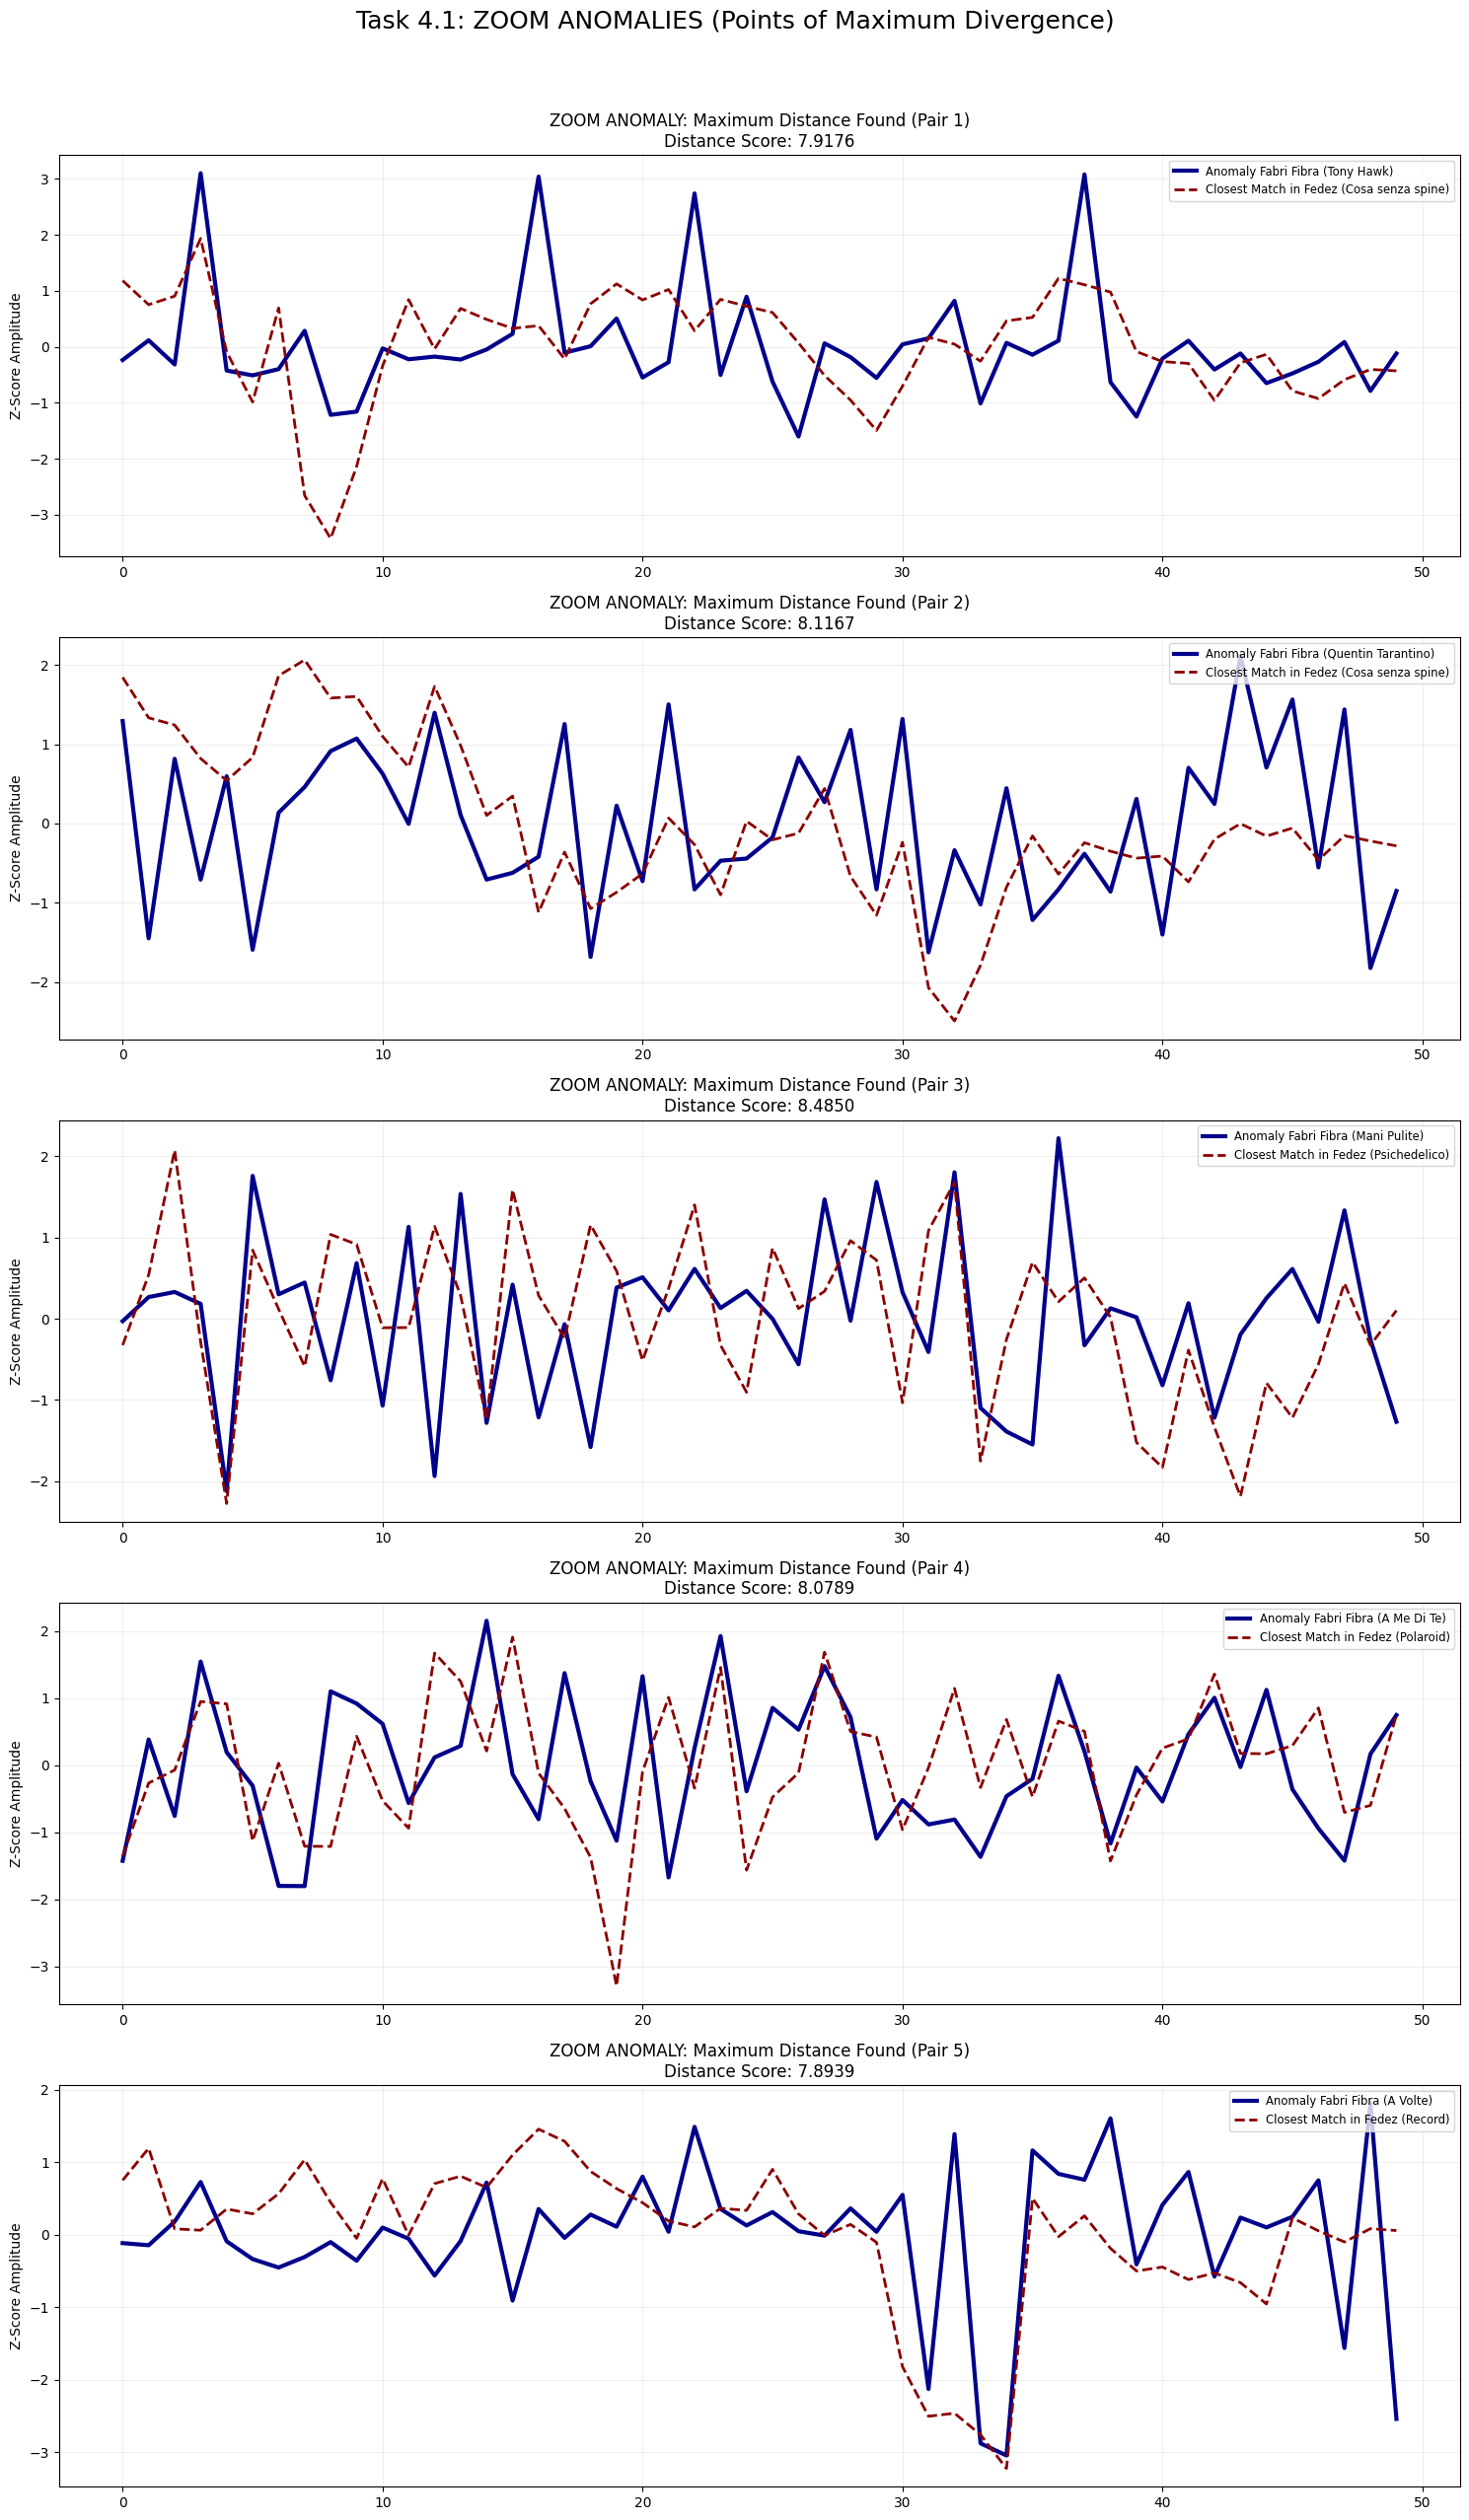

In [34]:
import stumpy
import numpy as np
import matplotlib.pyplot as plt

# Window of ~2 seconds
m = 50 

fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Task 4.1: ZOOM ANOMALIES (Points of Maximum Divergence)', fontsize=18, y=1.02)

# Using the top cross-artist matches in Cluster 1
for i, (index, row) in enumerate(df_meta_twins.head(5).iterrows()):
    # 1. Retrieve indices from synchronized metadata
    idx_a = df_analysis[df_analysis['track_id'] == row['id_1']].index[0]
    idx_b = df_analysis[df_analysis['track_id'] == row['id_2']].index[0]
    
    # 2. Extract 1D Time Series (Mean MFCC)
    s_a = X[idx_a, :, :].mean(axis=1).flatten().astype(float)
    s_b = X[idx_b, :, :].mean(axis=1).flatten().astype(float)
    
    # 3. STUMP AB-join: Calculate the distance of every subsequence in A relative to B
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b, ignore_trivial=False)
    
    # The CROSS-ARTIST ANOMALY is the point of MAXIMUM distance (argmax)
    # This is the section of Fedez that looks LEAST like any section of Fibra
    idx_a_discord = np.argmax(comp_mp[:, 0])
    
    # We still find the "least distant" point in B for visual contrast
    idx_b_nearest = comp_mp[idx_a_discord, 1]
    
    # 4. Segment Extraction
    seg_a = s_a[idx_a_discord : idx_a_discord + m]
    seg_b = s_b[idx_b_nearest : idx_b_nearest + m]
    
    # Z-Normalization for shape comparison
    seg_a_norm = (seg_a - np.mean(seg_a)) / np.std(seg_a)
    seg_b_norm = (seg_b - np.mean(seg_b)) / np.std(seg_b)
    
    # 5. Plotting
    ax = axes[i]
    ax.plot(seg_a_norm, label=f"Anomaly {row['artist_1']} ({row['song_1']})", lw=3, color='darkblue')
    ax.plot(seg_b_norm, label=f"Closest Match in {row['artist_2']} ({row['song_2']})", lw=2, color='darkred', linestyle='--')
    
    ax.set_title(f"ZOOM ANOMALY: Maximum Distance Found (Pair {i+1})\nDistance Score: {comp_mp[idx_a_discord, 0]:.4f}")
    ax.set_ylabel("Z-Score Amplitude")
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## ---------------------------------- corretto fino a qui-------------------------------------------

# Shapelet Analysis

In [52]:
from tslearn.shapelets import LearningShapelets
from tslearn.utils import to_time_series_dataset

# 1. Prepariamo il dataset (tslearn vuole un formato specifico)
# Usiamo X_final che contiene le tue serie temporali 500x13
X_shape = to_time_series_dataset(X_final)
y_shape = y_true # 0 per Fedez, 1 per Fibra

# 2. Configuriamo il modello
# Cerchiamo 1 shapelet di lunghezza 50 (circa 2-3 secondi di audio)
n_shapelets = 1
shapelet_length = 50
lpdtw = LearningShapelets(n_shapelets_per_size={shapelet_length: n_shapelets},
                          max_iter=100,
                          verbose=0,
                          random_state=42)

# 3. Addestramento (il modello "impara" la forma distintiva)
print("Estrazione della Shapelet in corso... potrebbe richiedere un momento.")
lpdtw.fit(X_shape, y_shape)

# 4. Recuperiamo la Shapelet imparata
# È una forma che rappresenta il "confine" tra i due artisti
shapelet_distintiva = lpdtw.shapelets_[0].flatten()

Estrazione della Shapelet in corso... potrebbe richiedere un momento.


d:\Anaconda\envs\mining_env\Lib\site-packages\tslearn\shapelets\shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


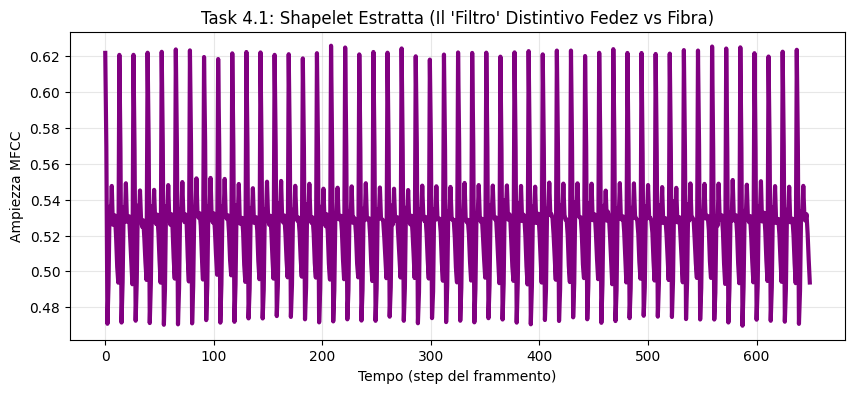

In [53]:
plt.figure(figsize=(10, 4))
plt.plot(shapelet_distintiva, color='purple', lw=3)
plt.title("Task 4.1: Shapelet Estratta (Il 'Filtro' Distintivo Fedez vs Fibra)")
plt.xlabel("Tempo (step del frammento)")
plt.ylabel("Ampiezza MFCC")
plt.grid(True, alpha=0.3)
plt.show()

## Multishapelet extraction

In [54]:
from tslearn.shapelets import LearningShapelets

# Definiamo diverse scale temporali: 25 step (~1s) e 100 step (~4s)
shapelet_sizes = {25: 2, 100: 1} 

ls = LearningShapelets(n_shapelets_per_size=shapelet_sizes,
                       max_iter=100,
                       random_state=42,
                       verbose=0)

ls.fit(X_shape, y_shape)

# Ora abbiamo 3 shapelets totali (2 corte, 1 lunga)
shapelets = ls.shapelets_

d:\Anaconda\envs\mining_env\Lib\site-packages\tslearn\shapelets\shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs

## Probability distribution analysis

### La vera analisi profonda consiste nel vedere quanto una canzone è "vicina" alla Shapelet di Fedez o a quella di Fibra. Questo trasforma una forma d'onda in un punteggio di probabilità

d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


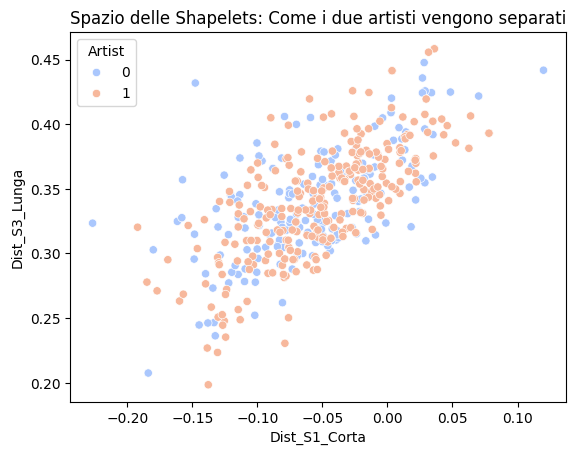

In [55]:
# Trasformiamo le serie temporali nello spazio delle distanze dalle shapelet
X_distances = ls.transform(X_shape)

# Creiamo un DataFrame per l'analisi
df_dist = pd.DataFrame(X_distances, columns=['Dist_S1_Corta', 'Dist_S2_Corta', 'Dist_S3_Lunga'])
df_dist['Artist'] = y_true # 0: Fedez, 1: Fibra

# Visualizziamo come le Shapelet separano i due artisti
sns.scatterplot(data=df_dist, x='Dist_S1_Corta', y='Dist_S3_Lunga', hue='Artist', palette='coolwarm')
plt.title("Spazio delle Shapelets: Come i due artisti vengono separati")
plt.show()

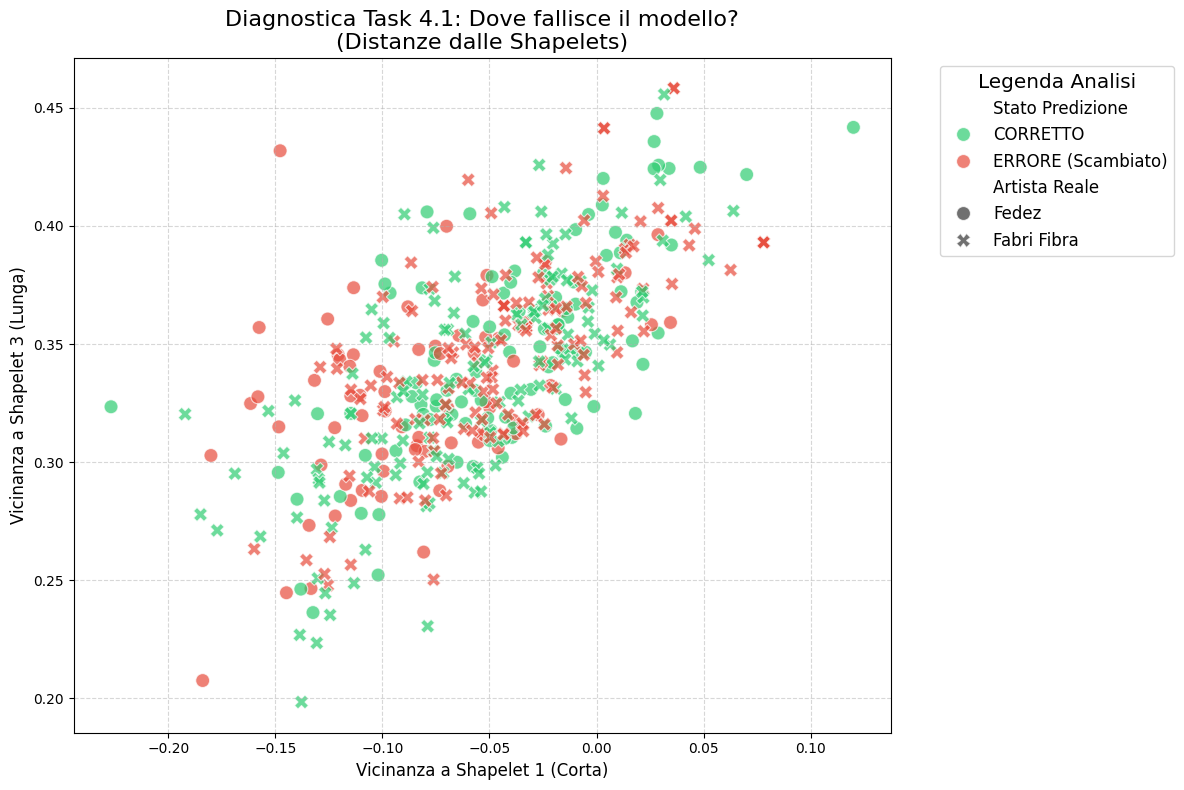

In [88]:
# Creiamo una colonna descrittiva per la legenda
df_dist['Stato Predizione'] = df_dist['Is_Error'].map({True: 'ERRORE (Scambiato)', False: 'CORRETTO'})
df_dist['Artista Reale'] = df_dist['Artist'].map({0: 'Fedez', 1: 'Fabri Fibra'})

plt.figure(figsize=(12, 8))

# Usiamo una palette molto contrastata: Rosso per l'errore, Verde per il corretto
palette_colori = {'ERRORE (Scambiato)': '#e74c3c', 'CORRETTO': '#2ecc71'}

sns.scatterplot(
    data=df_dist, 
    x='Dist_S1_Corta', 
    y='Dist_S3_Lunga', 
    hue='Stato Predizione',   # Il colore dice se il modello ha sbagliato
    style='Artista Reale',    # La forma (cerchio/croce) dice chi è l'autore
    palette=palette_colori,
    s=100,                    # Punti più grandi per vederli meglio
    alpha=0.7,
    edgecolor='w'
)

# Spostiamo la legenda fuori dal grafico per non coprire i punti
plt.legend(title='Legenda Analisi', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='large', title_fontsize='x-large')

plt.title("Diagnostica Task 4.1: Dove fallisce il modello?\n(Distanze dalle Shapelets)", fontsize=16)
plt.xlabel("Vicinanza a Shapelet 1 (Corta)", fontsize=12)
plt.ylabel("Vicinanza a Shapelet 3 (Lunga)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analisi "Localizzativa": Dove appare la Shapelet?
### Questa è la parte più descrittiva: prendiamo una canzone dove il modello ha sbagliato e cerchiamo se la "Shapelet di Fibra" appare comunque, traendo in inganno il sistema.

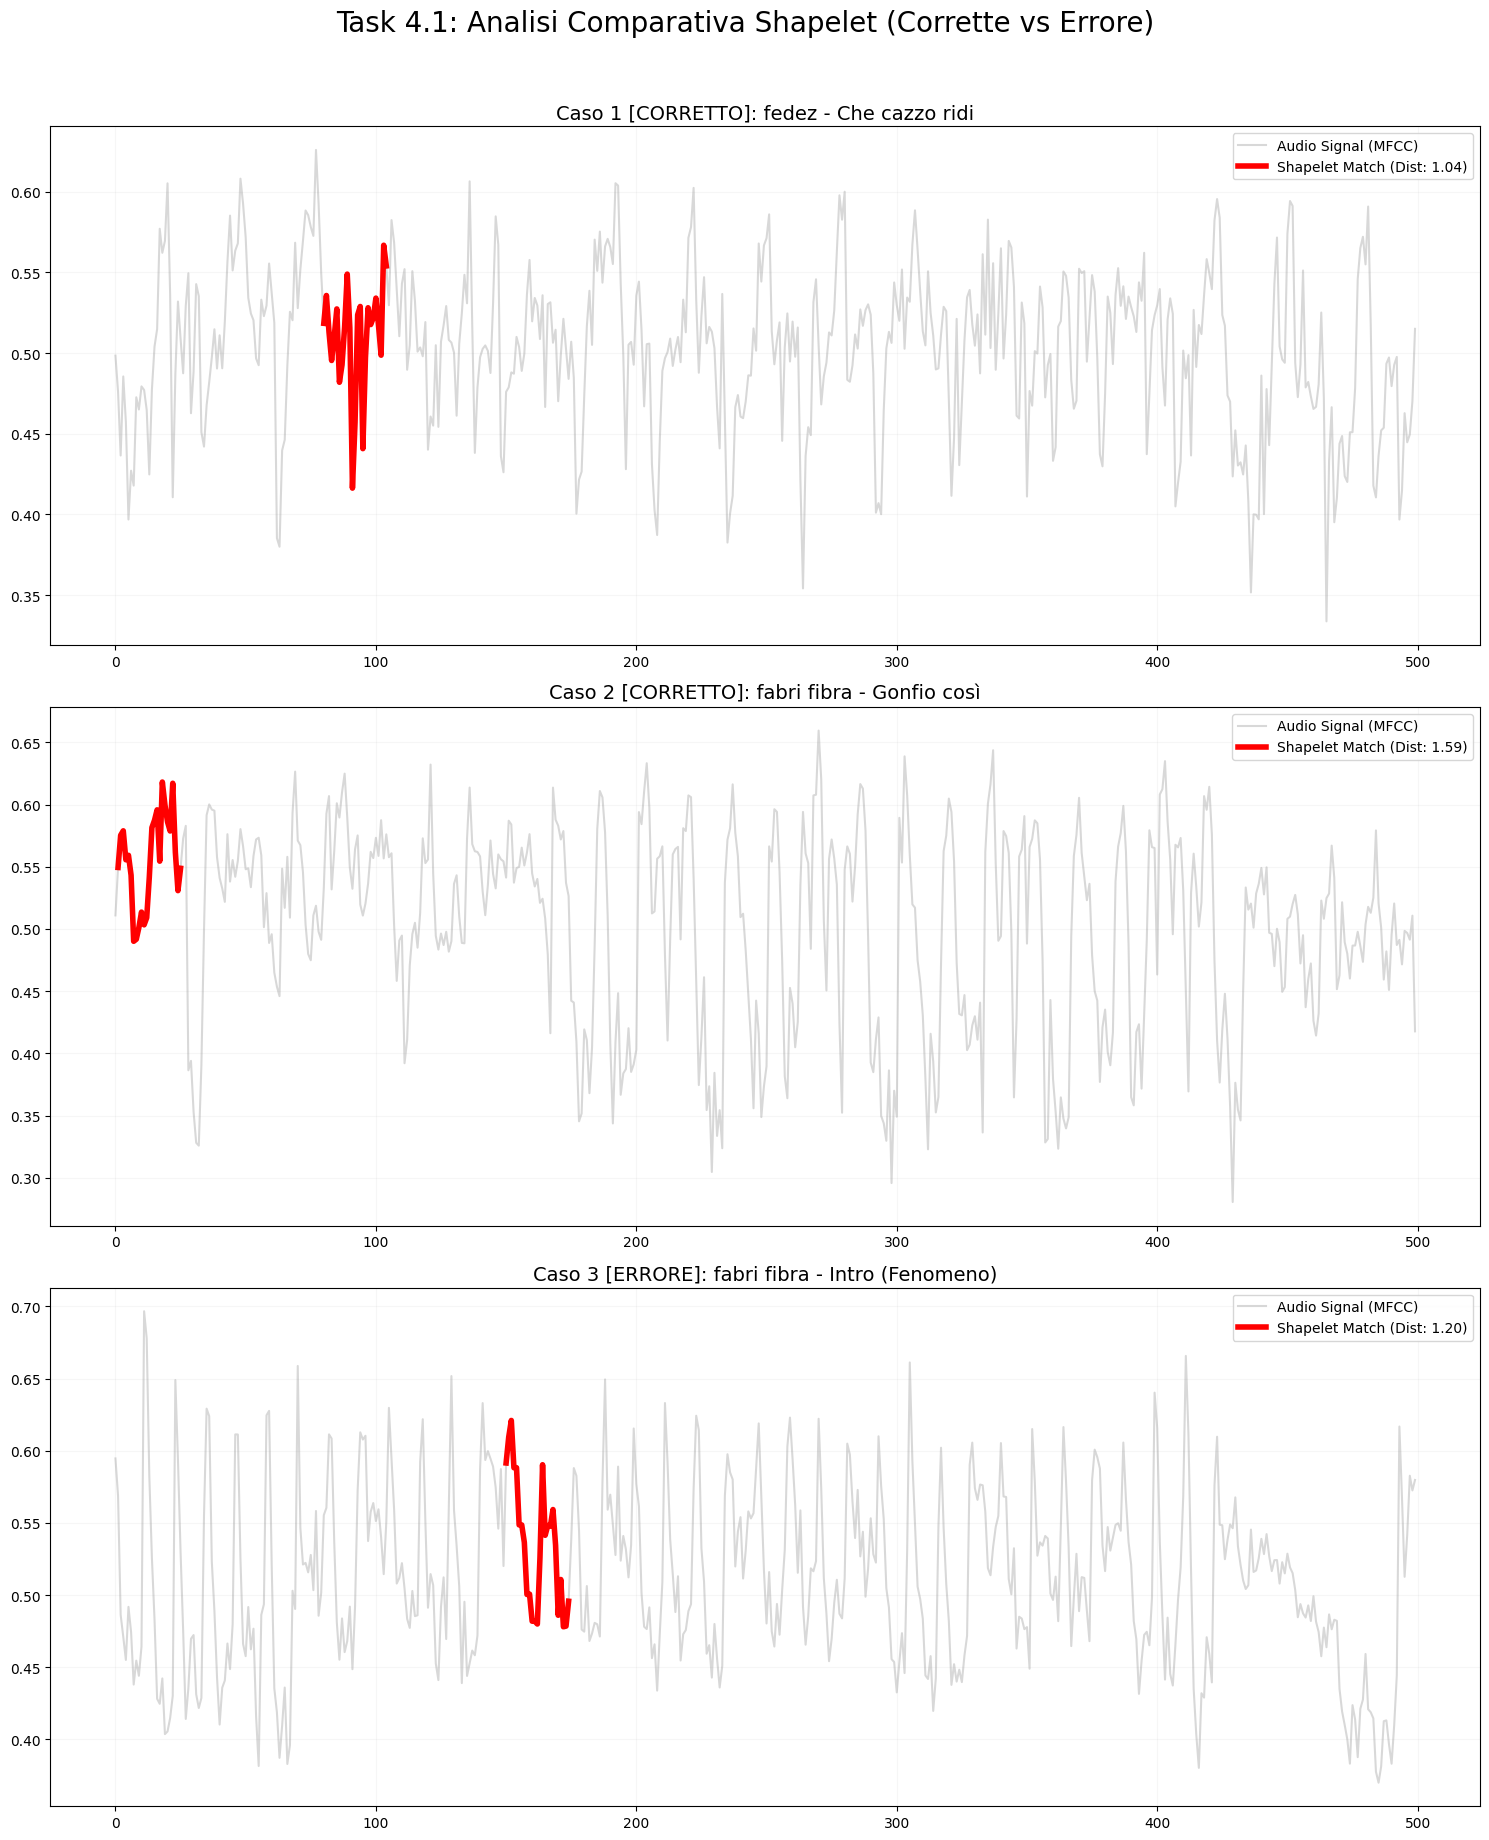

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def get_best_shapelet_match(idx_song, shapelet):
    ts = X_final[idx_song, :, :].mean(axis=1).flatten().astype(float)
    s = shapelet.flatten()
    # Calcolo distanza sliding window
    distances = [np.linalg.norm(ts[i:i+len(s)] - s) for i in range(len(ts)-len(s))]
    return ts, np.argmin(distances), np.min(distances)

# 1. Identifichiamo i tre casi (cambia gli indici se necessario)
# Caso A: Un Fedez predetto correttamente (non deve essere negli error_tr_codes)
id_fedez_ok = df[(df['name_artist'] == 'fedez') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso B: Un Fibra predetto correttamente
id_fibra_ok = df[(df['name_artist'] == 'fabri fibra') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso C: L'errore puro che abbiamo isolato prima
id_errore = errori_puri_ids[0]

casi = [id_fedez_ok, id_fibra_ok, id_errore]
shapelet_da_testare = shapelets[0] # La prima shapelet imparata

fig, axes = plt.subplots(3, 1, figsize=(15, 18))
fig.suptitle('Task 4.1: Analisi Comparativa Shapelet (Corrette vs Errore)', fontsize=20, y=1.02)

for i, track_id in enumerate(casi):
    idx = get_row_index(track_id)
    info = df.iloc[idx]
    ts, best_idx, dist = get_best_shapelet_match(idx, shapelet_da_testare)
    
    ax = axes[i]
    ax.plot(ts, color='gray', alpha=0.3, label='Audio Signal (MFCC)')
    # Evidenzio il match della shapelet
    ax.plot(range(best_idx, best_idx+len(shapelet_da_testare)), 
            ts[best_idx:best_idx+len(shapelet_da_testare)], 
            color='red', lw=4, label=f'Shapelet Match (Dist: {dist:.2f})')
    
    # Titolo dinamico
    tipo = "CORRETTO" if track_id not in error_tr_codes else "ERRORE"
    ax.set_title(f"Caso {i+1} [{tipo}]: {info['name_artist']} - {info['title']}", fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

In [61]:
# Vediamo quanti errori ha fatto il modello per ogni artista
error_df = df[df['track_id'].isin(error_tr_codes)]
print("Distribuzione degli errori per artista reale:")
print(error_df['name_artist'].value_counts())

Distribuzione degli errori per artista reale:
name_artist
fabri fibra    142
fedez           69
Name: count, dtype: int64


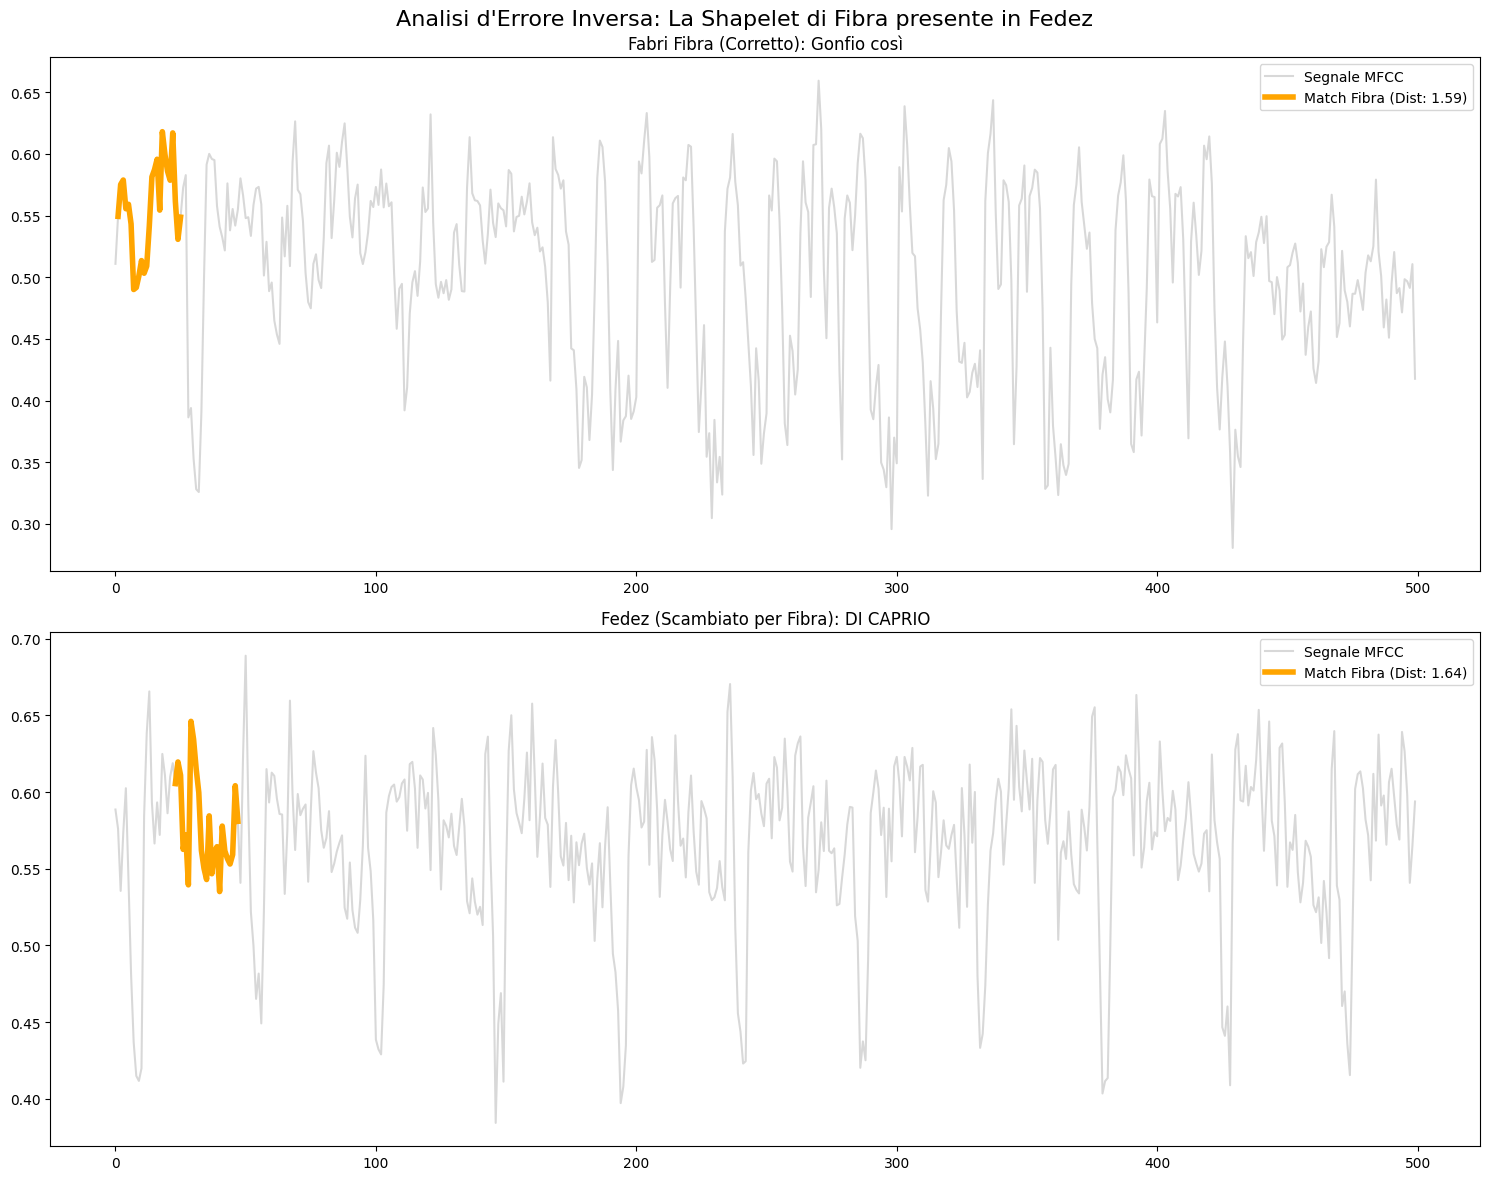

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Troviamo una Shapelet specifica per Fabri Fibra (Classe 1)
# Calcoliamo la distanza media di ogni shapelet dai brani di Fibra (y=1)
X_distances = ls.transform(X_shape)
mean_dist_fibra = X_distances[y_true == 1].mean(axis=0)
best_shapelet_idx_fibra = np.argmin(mean_dist_fibra)
shapelet_fibra = ls.shapelets_[best_shapelet_idx_fibra]

# 2. Selezioniamo i due casi per il confronto inverso
# Caso A: Fabri Fibra riconosciuto correttamente
id_fibra_ok = df[(df['name_artist'] == 'fabri fibra') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso B: Fedez riconosciuto ERRONEAMENTE come Fibra
# Cerchiamo un brano dove l'artista reale è Fedez ma il modello ha fallito assegnandolo a Fibra
id_fedez_scambiato = df[(df['name_artist'] == 'fedez') & (df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

casi_confronto_inv = [id_fibra_ok, id_fedez_scambiato]
titles_inv = ["Fabri Fibra (Corretto)", "Fedez (Scambiato per Fibra)"]

fig, axes = plt.subplots(2, 1, figsize=(15, 12))
fig.suptitle('Analisi d\'Errore Inversa: La Shapelet di Fibra presente in Fedez', fontsize=16)

for i, track_id in enumerate(casi_confronto_inv):
    idx = get_row_index(track_id)
    ts, best_idx, dist = get_best_shapelet_match(idx, shapelet_fibra)
    
    # ESTRAIAMO IL SEGMENTO PER NORMALIZZARLO (Z-Score)
    segmento = ts[best_idx:best_idx+len(shapelet_fibra)]
    # (segmento - media) / deviazione standard per vedere la FORMA pura
    seg_norm = (segmento - np.mean(segmento)) / (np.std(segmento) + 1e-8)
    sha_norm = (shapelet_fibra.flatten() - np.mean(shapelet_fibra)) / (np.std(shapelet_fibra) + 1e-8)

    ax = axes[i]
    # Plottiamo il segnale originale in sottofondo
    ax.plot(ts, color='gray', alpha=0.3, label='Segnale MFCC')
    
    # Evidenziamo il match
    ax.plot(range(best_idx, best_idx+len(shapelet_fibra)), 
            ts[best_idx:best_idx+len(shapelet_fibra)], 
            color='orange', lw=4, label=f'Match Fibra (Dist: {dist:.2f})')
    
    ax.set_title(f"{titles_inv[i]}: {df.iloc[idx]['title']}")
    ax.legend()
plt.tight_layout()
plt.show()

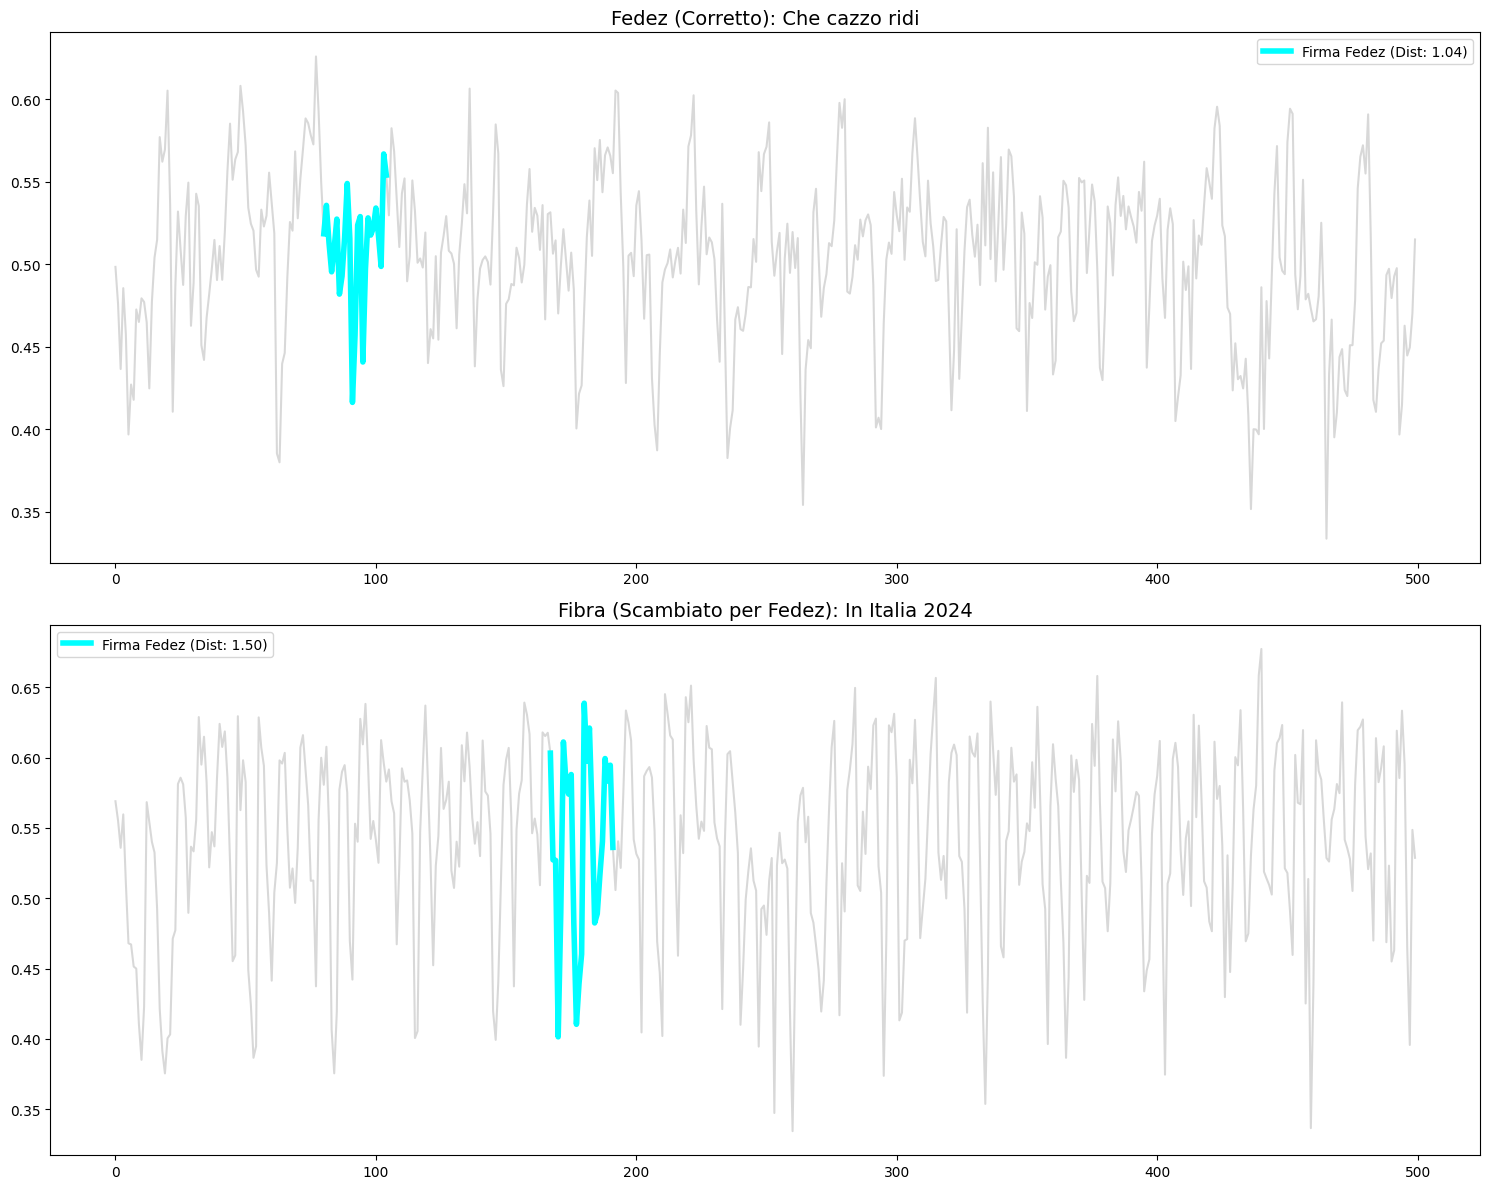

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# 1. IDENTIFICAZIONE COMPLETA ERRORI (Fibra -> Fedez E Fedez -> Fibra)
idx_fibra_as_fedez = np.where((y_true == 1) & (y_pred == 0))[0]
idx_fedez_as_fibra = np.where((y_true == 0) & (y_pred == 1))[0]

error_tr_codes = [names[i].split(' - ')[-1].replace('.mp3', '') for i in np.concatenate([idx_fibra_as_fedez, idx_fedez_as_fibra])]

# 2. SELEZIONE SHAPELET DISCRIMINANTE PER FEDEZ
# Cerchiamo la shapelet che minimizza la distanza dai brani di Fedez (classe 0)
# X_distances ha dimensioni (n_samples, n_shapelets)
X_distances = ls.transform(X_shape)
dist_fedez = X_distances[y_true == 0].mean(axis=0)
dist_fibra = X_distances[y_true == 1].mean(axis=0)

# La migliore shapelet per Fedez è quella che è vicina a lui ma LONTANA da Fibra
best_shapelet_idx = np.argmin(dist_fedez - dist_fibra) 
shapelet_fedez = ls.shapelets_[best_shapelet_idx]

# 3. PREPARAZIONE CONFRONTO (Errore vs Corretto)
# Prendiamo un Fedez OK e un Fibra scambiato per Fedez
id_fedez_ok = df[(df['name_artist'].str.lower() == 'fedez') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]
id_fibra_err = names[idx_fibra_as_fedez[0]].split(' - ')[-1].replace('.mp3', '')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

for ax, t_id, title in zip([ax1, ax2], [id_fedez_ok, id_fibra_err], ["Fedez (Corretto)", "Fibra (Scambiato per Fedez)"]):
    idx = get_row_index(t_id)
    ts, b_idx, d = get_best_shapelet_match(idx, shapelet_fedez)
    
    ax.plot(ts, color='gray', alpha=0.3)
    ax.plot(range(b_idx, b_idx+len(shapelet_fedez)), ts[b_idx:b_idx+len(shapelet_fedez)], 
            color='cyan', lw=4, label=f'Firma Fedez (Dist: {d:.2f})')
    ax.set_title(f"{title}: {df.iloc[idx]['title']}", fontsize=14)
    ax.legend()

plt.tight_layout()
plt.show()